## Load package

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 300

import numpy as np
import bayesflow as bf
import copy
from scipy.stats import norm, t
import random
import gc
from tqdm.notebook import tqdm
from pathlib import Path
import ipynbname
RNG = np.random.default_rng(2023)

C:\ProgramData\miniconda3\Lib\site-packages\bayesflow\trainers.py:27: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## Get file path

In [2]:
notebook_path = Path(ipynbname.path()).resolve().parent
root_dir = notebook_path.parent

## Get checkpoint path

In [3]:
checkpoint_path_standard = root_dir/ "networks/standard"
checkpoint_path_df1 = root_dir/ "networks/df1"
checkpoint_path_df3 = root_dir/ "networks/df3"
checkpoint_path_df5 = root_dir/ "networks/df5"

checkpoint_path_standard_cost = root_dir/ "networks/cost of robustness/standard"
checkpoint_path_df1_cost =  root_dir/ "networks/cost of robustness/df1"
checkpoint_path_df3_cost =  root_dir/ "networks/cost of robustness/df3"
checkpoint_path_df5_cost =  root_dir/ "networks/cost of robustness/df5"

checkpoint_path_df1_001 = root_dir/ "networks/contamination probablity/pi=0.01"
checkpoint_path_df1_005 = root_dir/ "networks/contamination probablity/pi=0.05"
checkpoint_path_df1_010 = root_dir/ "networks/contamination probablity/pi=0.10"
checkpoint_path_df1_020 = root_dir/ "networks/contamination probablity/pi=0.20"

## Train a standard model

In [4]:
D=1
def prior_fun(D=D):
    return RNG.normal(size=D)

PARAM_NAMES = [
    r'$\mu$'
]

prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)



#default scale is 1
def likelihood_fun(params,n_obs = RNG.integers(10,101)):
    return RNG.normal(loc=params, size=(n_obs, params.shape[0]))

simulator = bf.simulation.Simulator(simulator_fun=likelihood_fun)

model = bf.simulation.GenerativeModel(prior=prior, simulator=simulator)

summary_net = bf.networks.DeepSet(summary_dim=2)

inference_net = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

amortizer = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

trainer = bf.trainers.Trainer(amortizer=amortizer, 
                              generative_model=model,
                              checkpoint_path = checkpoint_path_standard)

## uncomment if you want train the networks yourself
#history = trainer.train_online(epochs=1, iterations_per_epoch=1000, batch_size=32)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 53, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\standard\history_10.pkl.
INFO:root:Networks loaded from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\standard\ckpt-10
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


## Simulators with different n

In [5]:
#n=10
def likelihood_fun_10(params, n_obs=10):
    return RNG.normal(loc=params, size=(n_obs, params.shape[0]))

simulator_10 = bf.simulation.Simulator(simulator_fun=likelihood_fun_10)
model_10 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_10)

#n=20
def likelihood_fun_20(params, n_obs=20):
    return RNG.normal(loc=params, size=(n_obs, params.shape[0]))

simulator_20 = bf.simulation.Simulator(simulator_fun=likelihood_fun_20)
model_20 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_20)

#n=100
def likelihood_fun_100(params, n_obs=100):
    return RNG.normal(loc=params, size=(n_obs, params.shape[0]))

simulator_100 = bf.simulation.Simulator(simulator_fun=likelihood_fun_100)
model_100 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_100)


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 10, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 20, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Performing 2 pilot runs with the anonymous m

## Analytical posterior mean vs. BayesFlow posterior mean

<Figure size 300x300 with 0 Axes>

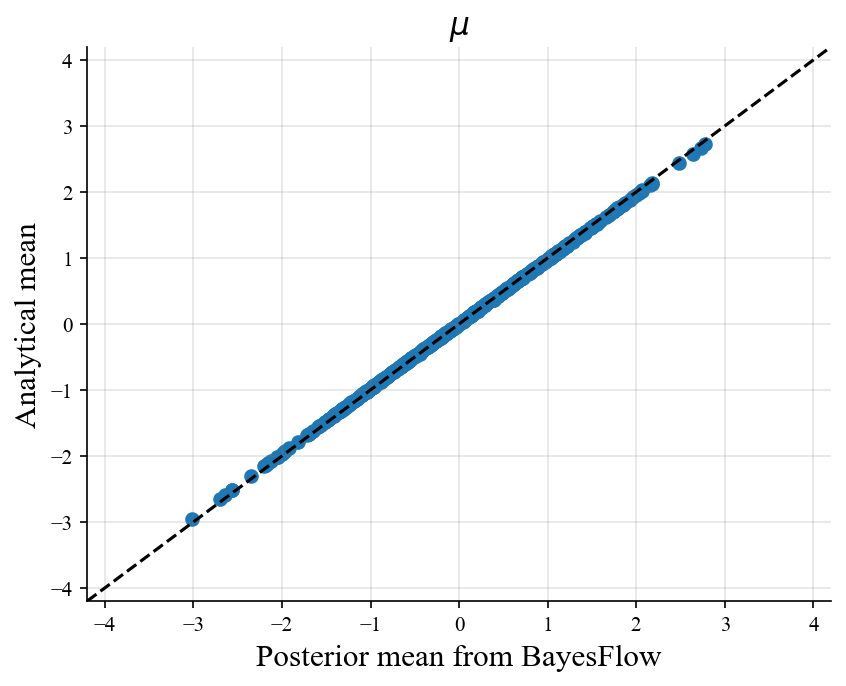

In [27]:
test_sims = trainer.configurator(model_20(500))
post_samples = amortizer.sample(test_sims, n_samples=1500)
test_sum = np.sum(test_sims['summary_conditions'], axis=1)
test_precision = 1/np.var(test_sims['summary_conditions'], axis=1)
analytical_mean = test_sum/21

plt.figure(figsize=(1, 1))
plt.figure(dpi=150)
plt.rcParams['font.family'] = 'Times New Roman'
plt.scatter(np.mean(post_samples, axis=1), analytical_mean)
plt.title(r'$\mu$',size=15)
post_samples = amortizer.sample(test_sims, n_samples=150)
plt.xlabel('Posterior mean from BayesFlow', size=15)
plt.ylabel('Analytical mean',size=15)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


# Set grey grid
plt.grid(color='grey', linestyle='-',alpha=0.2)


plt.tick_params(axis='x', labelsize=10)
plt.tick_params(axis='y', labelsize=10)

plt.xlim(-4.2, 4.2)
plt.ylim(-4.2, 4.2)
plt.plot([-4.2, 4.2], [-4.2, 4.2], linestyle='--', color='black')


## Parameter recovery of the standard estimator

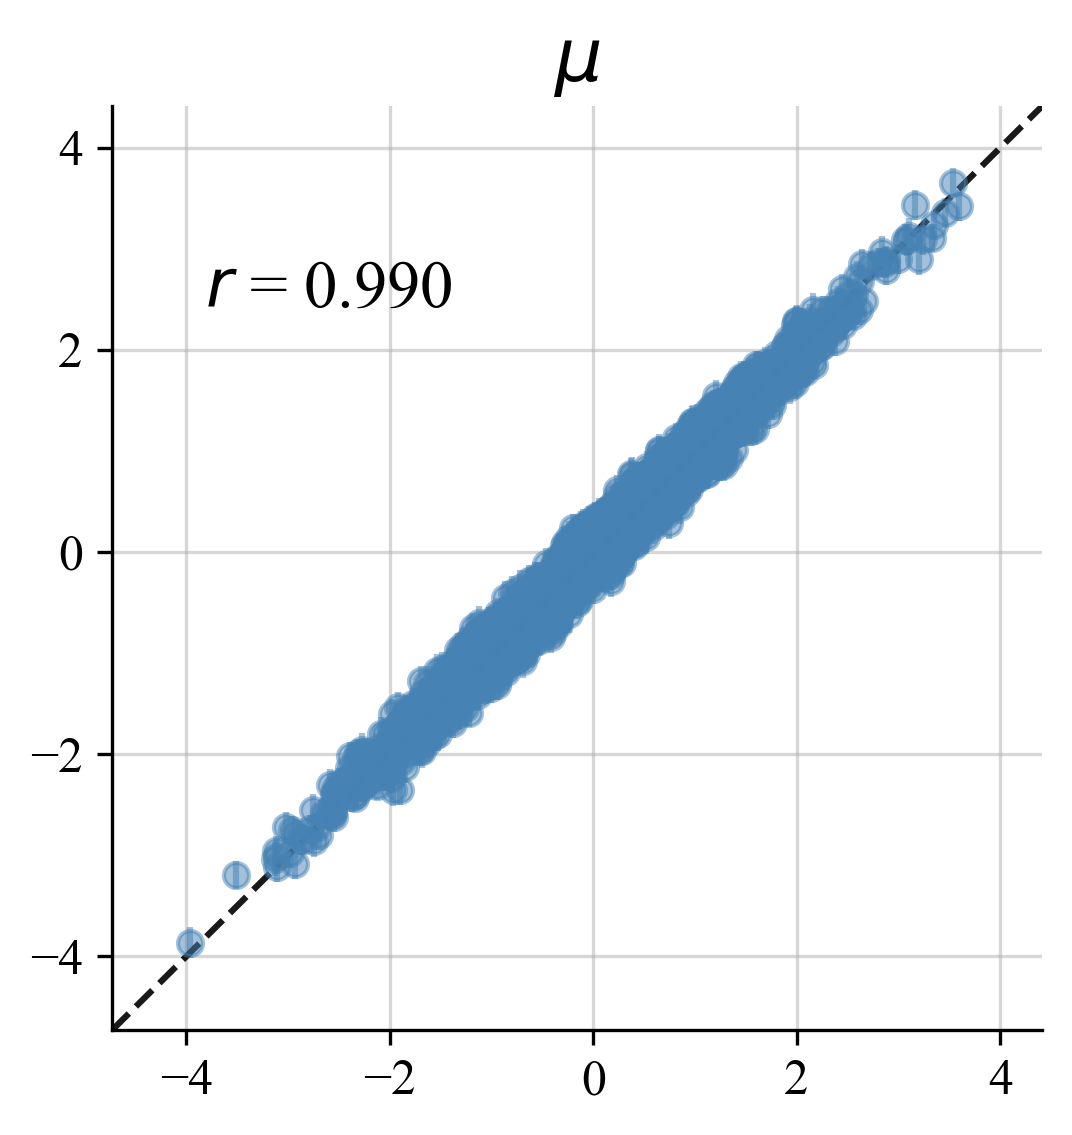

In [7]:
test_sims = trainer.configurator(model(5000))
post_samples = amortizer.sample(test_sims, n_samples=150)
plt.rcParams['font.family'] = 'Times New Roman'

try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='steelblue',add_r2=False)
    plt.show()
    
except Exception as e:
    # Suppress the error and continue execution
    pass


## Stylized Empirical influence function

In [6]:
#n=1000
def likelihood_fun_1000(params, n_obs=1000):
    return RNG.normal(loc=params, size=(n_obs, params.shape[0]))

simulator_1000 = bf.simulation.Simulator(simulator_fun=likelihood_fun_1000)
model_1000 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_1000)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 1000, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [7]:
def obtain_quantile(batch_size, sample_size):
    #simulate n datasets
    sim_data = model_1000(batch_size)
    num_trials = 1000
    sim_data_quantile = {}
    data = sim_data["sim_data"]

    sim_data_array = np.empty((batch_size, sample_size, 1))
    
    quantile = (np.arange(1,sample_size + 1) - 0.5) / sample_size
    sim_data_quantile["sim_data"] = np.percentile(model_1000(batch_size)["sim_data"].reshape(batch_size, 1000), quantile*100, axis = 1).reshape(batch_size, sample_size, 1)
    sim_data_quantile["sim_batchable_context"] = None
    sim_data_quantile["sim_non_batchable_context"] = None
    sim_data_quantile["prior_batchable_context"] = None
    sim_data_quantile["prior_non_batchable_context"] = None
    sim_data_quantile["prior_draws"] = None
    
    return sim_data_quantile

In [8]:
#define the stylized sensitivity curve
def compute_ssc(xinfl, batch_size,  sample_size, n_samples=150):
    nrx=len(xinfl)
    infl_mean = np.zeros(shape=nrx)
    infl_mean_upper = np.zeros(shape=nrx)
    infl_mean_lower = np.zeros(shape=nrx)
    infl_median = np.zeros(shape=nrx)
    infl_median_upper = np.zeros(shape=nrx)
    infl_median_lower = np.zeros(shape=nrx)
    
    for j in tqdm(range(nrx), desc="Progress", leave=False):
        sim_data = obtain_quantile(batch_size, sample_size)
        sim_data_orig = copy.deepcopy(sim_data)
        x_c = xinfl[j] * np.ones((batch_size, 1 ,1))
        sim_data['sim_data'] = np.concatenate((sim_data["sim_data"], x_c), axis = 1)
    
        #inference from BF
        diff_mean = np.mean(sim_data['sim_data'], axis = 1) - np.mean(sim_data_orig['sim_data'], axis = 1)
        diff_median = np.median(sim_data['sim_data'], axis = 1) - np.median(sim_data_orig['sim_data'], axis = 1)
    
        
        infl_mean[j] = np.mean(diff_mean)
        infl_mean_upper[j] = np.percentile(diff_mean, 97.5)
        infl_mean_lower[j] = np.percentile(diff_mean, 2.5)

        infl_median[j] = np.mean(diff_median)
        infl_median_upper[j] = np.percentile(diff_median, 97.5)
        infl_median_lower[j] = np.percentile(diff_median, 2.5)
    
    
    return infl_mean, infl_mean_upper, infl_mean_lower, infl_median, infl_median_upper, infl_median_lower


In [12]:
xinfl = np.arange(-100, 100, 1)
infl_mean, infl_mean_upper, infl_mean_lower, infl_median, infl_median_upper, infl_median_lower= compute_ssc(xinfl = xinfl, sample_size = 10, batch_size = 200)

Progress:   0%|          | 0/200 [00:00<?, ?it/s]

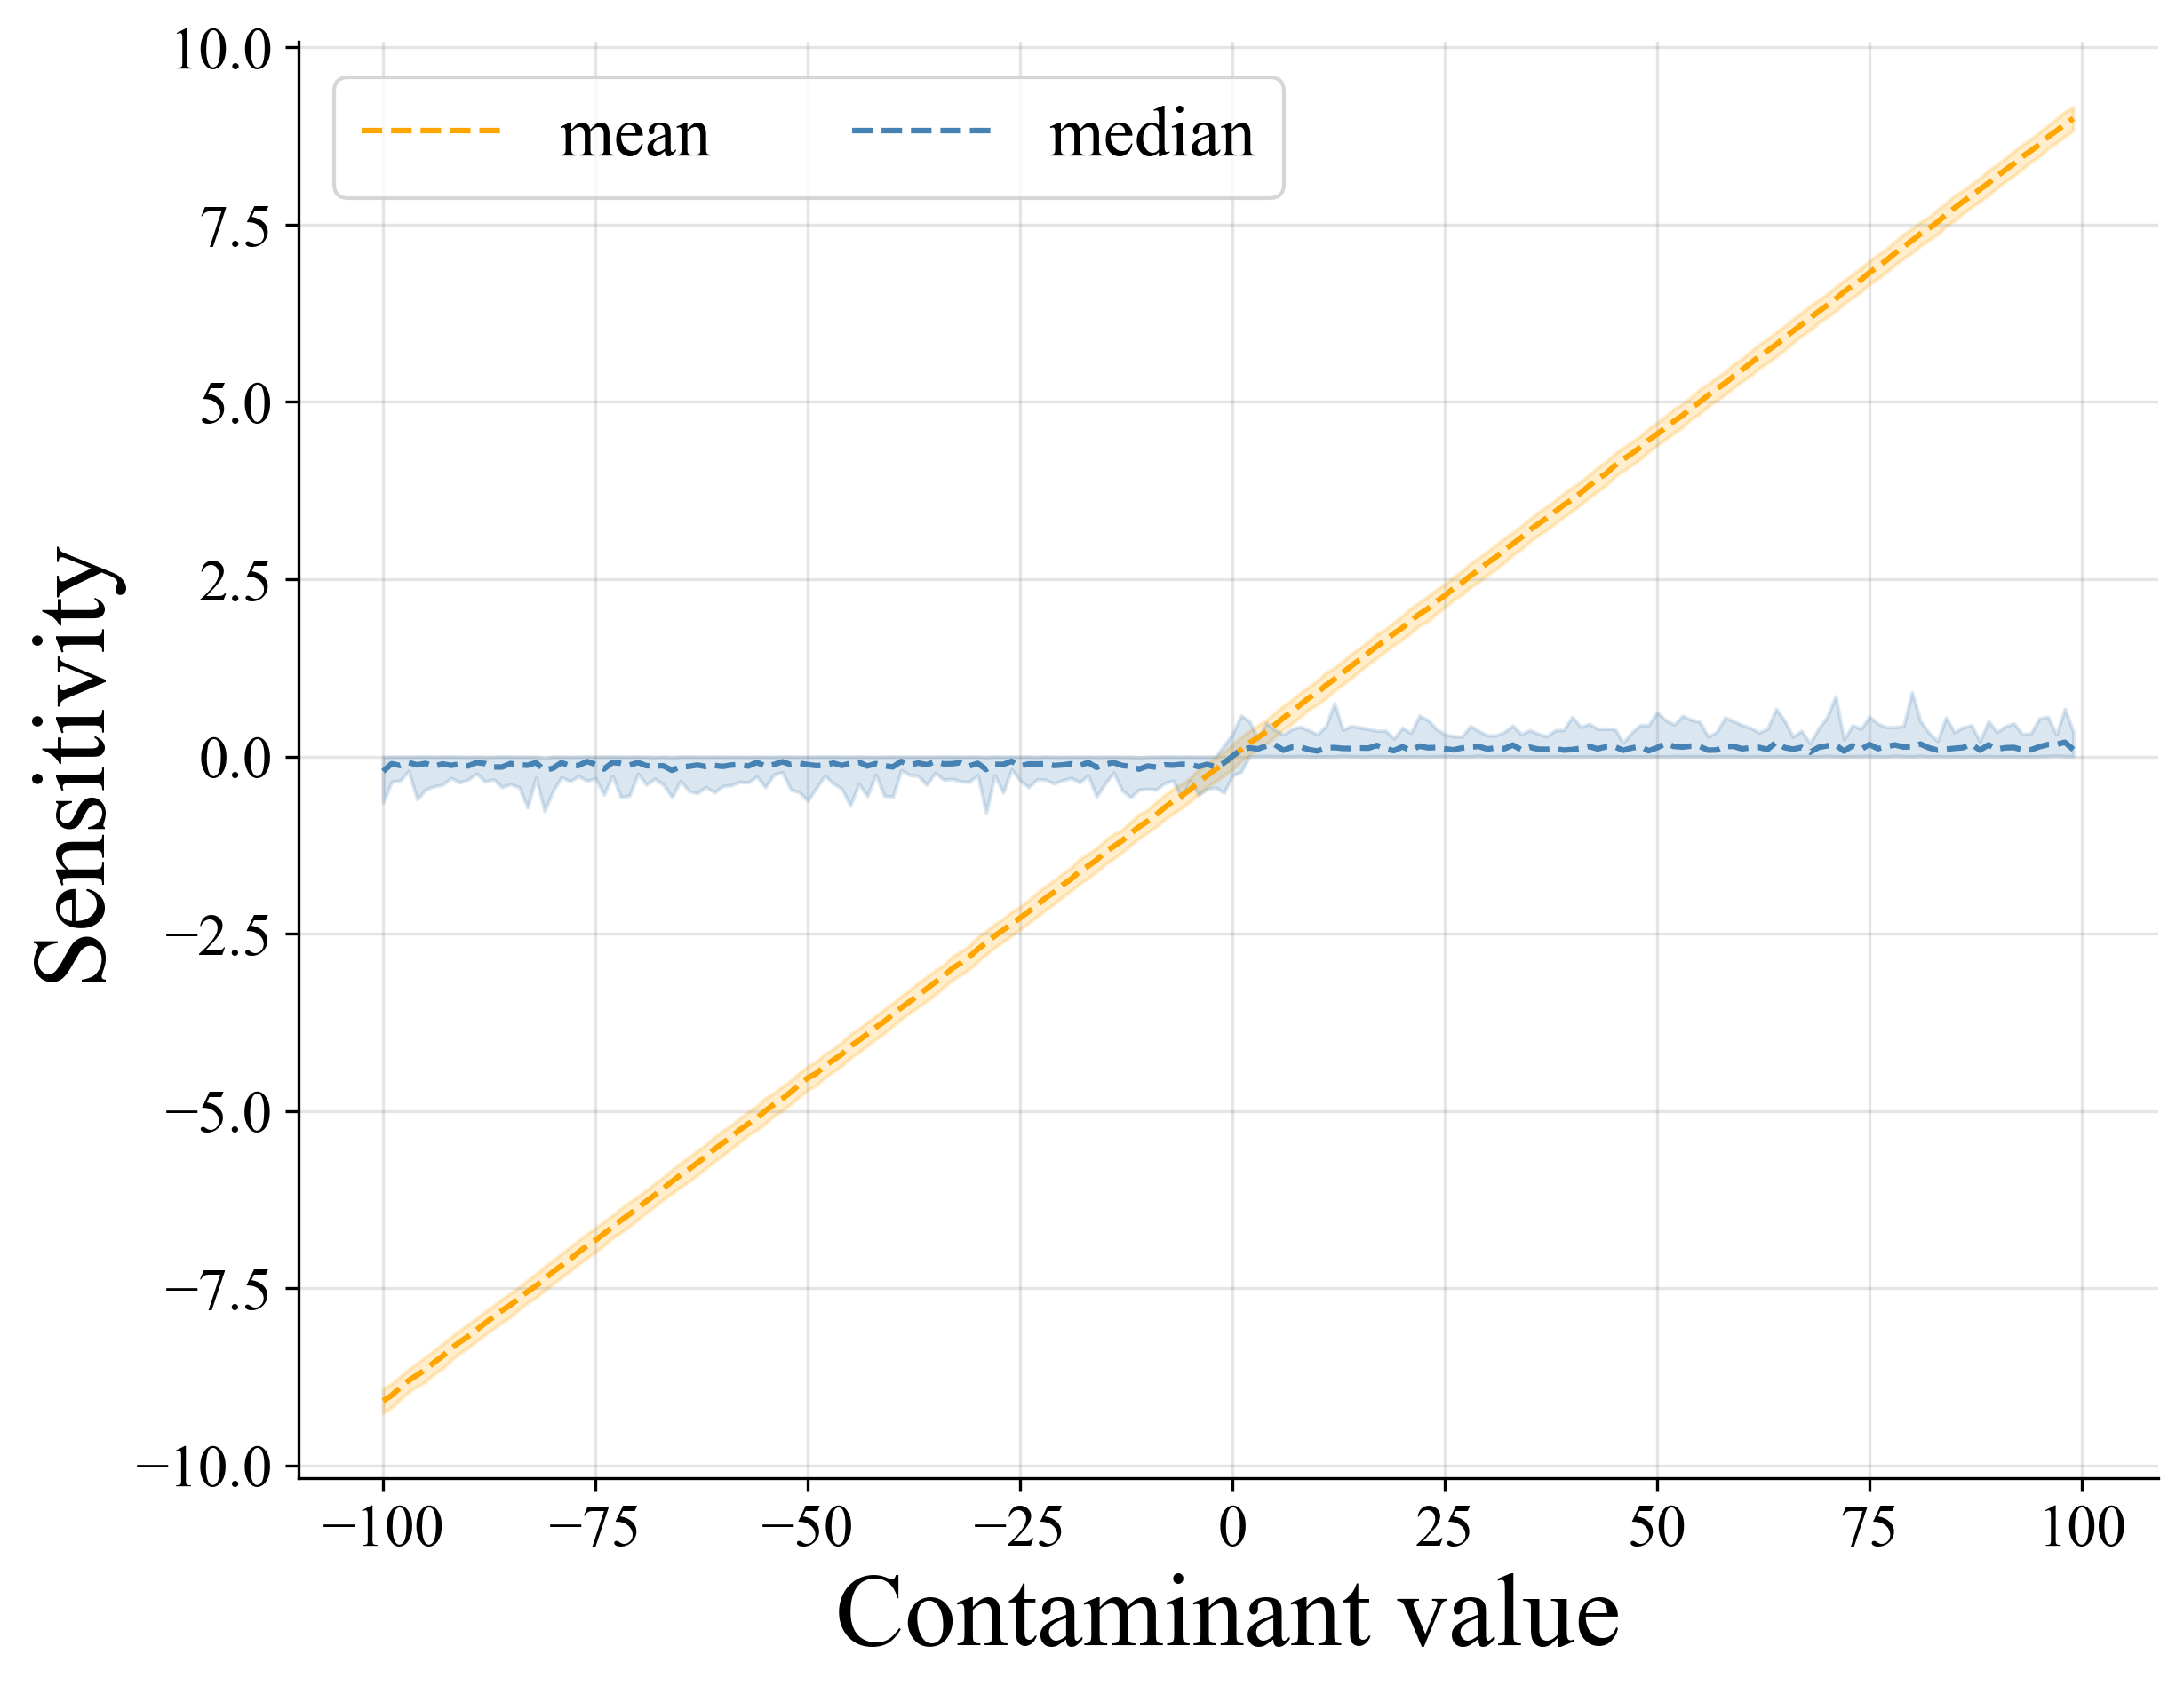

In [13]:
xinfl = np.arange(-100, 100, 1)
# Plot the SSC
plt.figure(figsize=(9, 7), dpi=300)
plt.rcParams['font.family'] = 'Times New Roman'

# Use current axis handle for fill_between
ax = plt.gca()

# Plot lines and confidence bands
ax.plot(xinfl, infl_mean, color='orange', linestyle='--', label='mean')
ax.fill_between(xinfl, infl_mean_lower, infl_mean_upper, color='orange', alpha=0.2)

ax.plot(xinfl, infl_median, color='steelblue', linestyle='--', label='median')
ax.fill_between(xinfl, infl_median_lower, infl_median_upper, color='steelblue', alpha=0.2)

# Labels
ax.set_xlabel('Contaminant value', fontsize=28)
ax.set_ylabel("Sensitivity", fontsize=28)

# Hide top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grey grid
ax.grid(color='grey', linestyle='-', alpha=0.2)

# Legend
ax.legend(ncol=2, loc="upper left", frameon=True, fontsize=19)

# Tick font size
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Save or show
#plt.savefig(root_dir/"plots/SSC_mean_median.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [33]:
#define the stylized sensitivity curve
def compute_ssc(xinfl, amortizer, batch_size,  sample_size, n_samples=150):
    nrx=len(xinfl)
    infl = np.zeros(shape=nrx)
    infl_upper = np.zeros(shape=nrx)
    infl_lower = np.zeros(shape=nrx)
    infl_theory = np.zeros(shape=nrx)
    
    for j in tqdm(range(nrx), desc="Progress", leave=False):
        sim_data = obtain_quantile(batch_size, sample_size)
        sim_data_orig = copy.deepcopy(sim_data)
        x_c = xinfl[j] * np.ones((batch_size, 1 ,1))
        sim_data['sim_data'] = np.concatenate((sim_data["sim_data"], x_c), axis = 1)
    
        #inference from BF
        post_samples = amortizer.sample(trainer.configurator(sim_data), n_samples=n_samples)
        post_samples_orig = amortizer.sample(trainer.configurator(sim_data_orig), n_samples=n_samples)
        avgpost = np.mean(post_samples, axis = 1)
        avgpost_orig = np.mean(post_samples_orig, axis = 1)
        diff = avgpost - avgpost_orig
    
        
        infl[j] = np.mean(diff)
        infl_upper[j] = np.percentile(diff, 97.5)
        infl_lower[j] = np.percentile(diff, 2.5)
        
    
    
        #inference in theory
        avg = np.mean(np.sum(sim_data['sim_data'], axis = 1)/(sample_size+2))
        avg_orig = np.mean(np.sum(sim_data_orig['sim_data'], axis = 1)/(sample_size+1))
        infl_theory[j]=avg-avg_orig
        
        del sim_data, sim_data_orig, post_samples, post_samples_orig
        gc.collect()  # Force garbage collection
    
    return infl, infl_upper, infl_lower, infl_theory


In [1]:
# Compute and store the EIF
xinfl = np.arange(-100, 100, 1)
infl_10, infl_10_upper, infl_10_lower, infl_theory_10 = compute_ssc(xinfl = xinfl, amortizer = amortizer, sample_size = 10, batch_size = 100)

infl_20, infl_20_upper, infl_20_lower, infl_theory_20 = compute_ssc(xinfl = xinfl, amortizer = amortizer, sample_size = 20, batch_size = 100)

infl_100, infl_100_upper, infl_100_lower, infl_theory_100 = compute_ssc(xinfl = xinfl, amortizer = amortizer, sample_size = 100, batch_size = 100)

## Breakdown point (BP) of the standard estimator

In [14]:
#Define BP
def compute_bp(ninfl, model, trainer, sample_size, batch_size=500,n_samples=150):
    nrx=len(ninfl)
    bp = np.zeros(shape=(nrx, 1))
    bp_theory = np.zeros(shape=(nrx, 1))
    
    for j in tqdm(range(nrx), desc="Progress", leave=False):
        sim_data = model(batch_size=batch_size)
        sim_data['sim_data'][:,0:ninfl[j]] = -100
        post_samples = amortizer.sample(trainer.configurator(sim_data), n_samples=n_samples)
        bp[j] = np.mean(np.mean(post_samples, axis=1))
    
        #inference in theory
        bp_theory[j] = np.mean(np.sum(sim_data['sim_data'], axis = 1)/(sample_size+1))
        
        del sim_data, post_samples
        gc.collect()  # Force garbage collection
    
    return bp, bp_theory

In [15]:
#Compute BP
ninfl_10 = np.arange(0,11,1)
ninfl_20 = np.arange(0,21,1)
ninfl_100 = np.arange(0,101,1)
bp_10, bp_theory_10 = compute_bp(ninfl=ninfl_10, model = model_10, trainer = trainer, sample_size=10)
bp_20, bp_theory_20 = compute_bp(ninfl=ninfl_20, model = model_20, trainer = trainer, sample_size=20)
bp_100, bp_theory_100 = compute_bp(ninfl=ninfl_100, model = model_100, trainer = trainer, sample_size=100)

Progress:   0%|          | 0/11 [00:00<?, ?it/s]

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Progress:   0%|          | 0/101 [00:00<?, ?it/s]

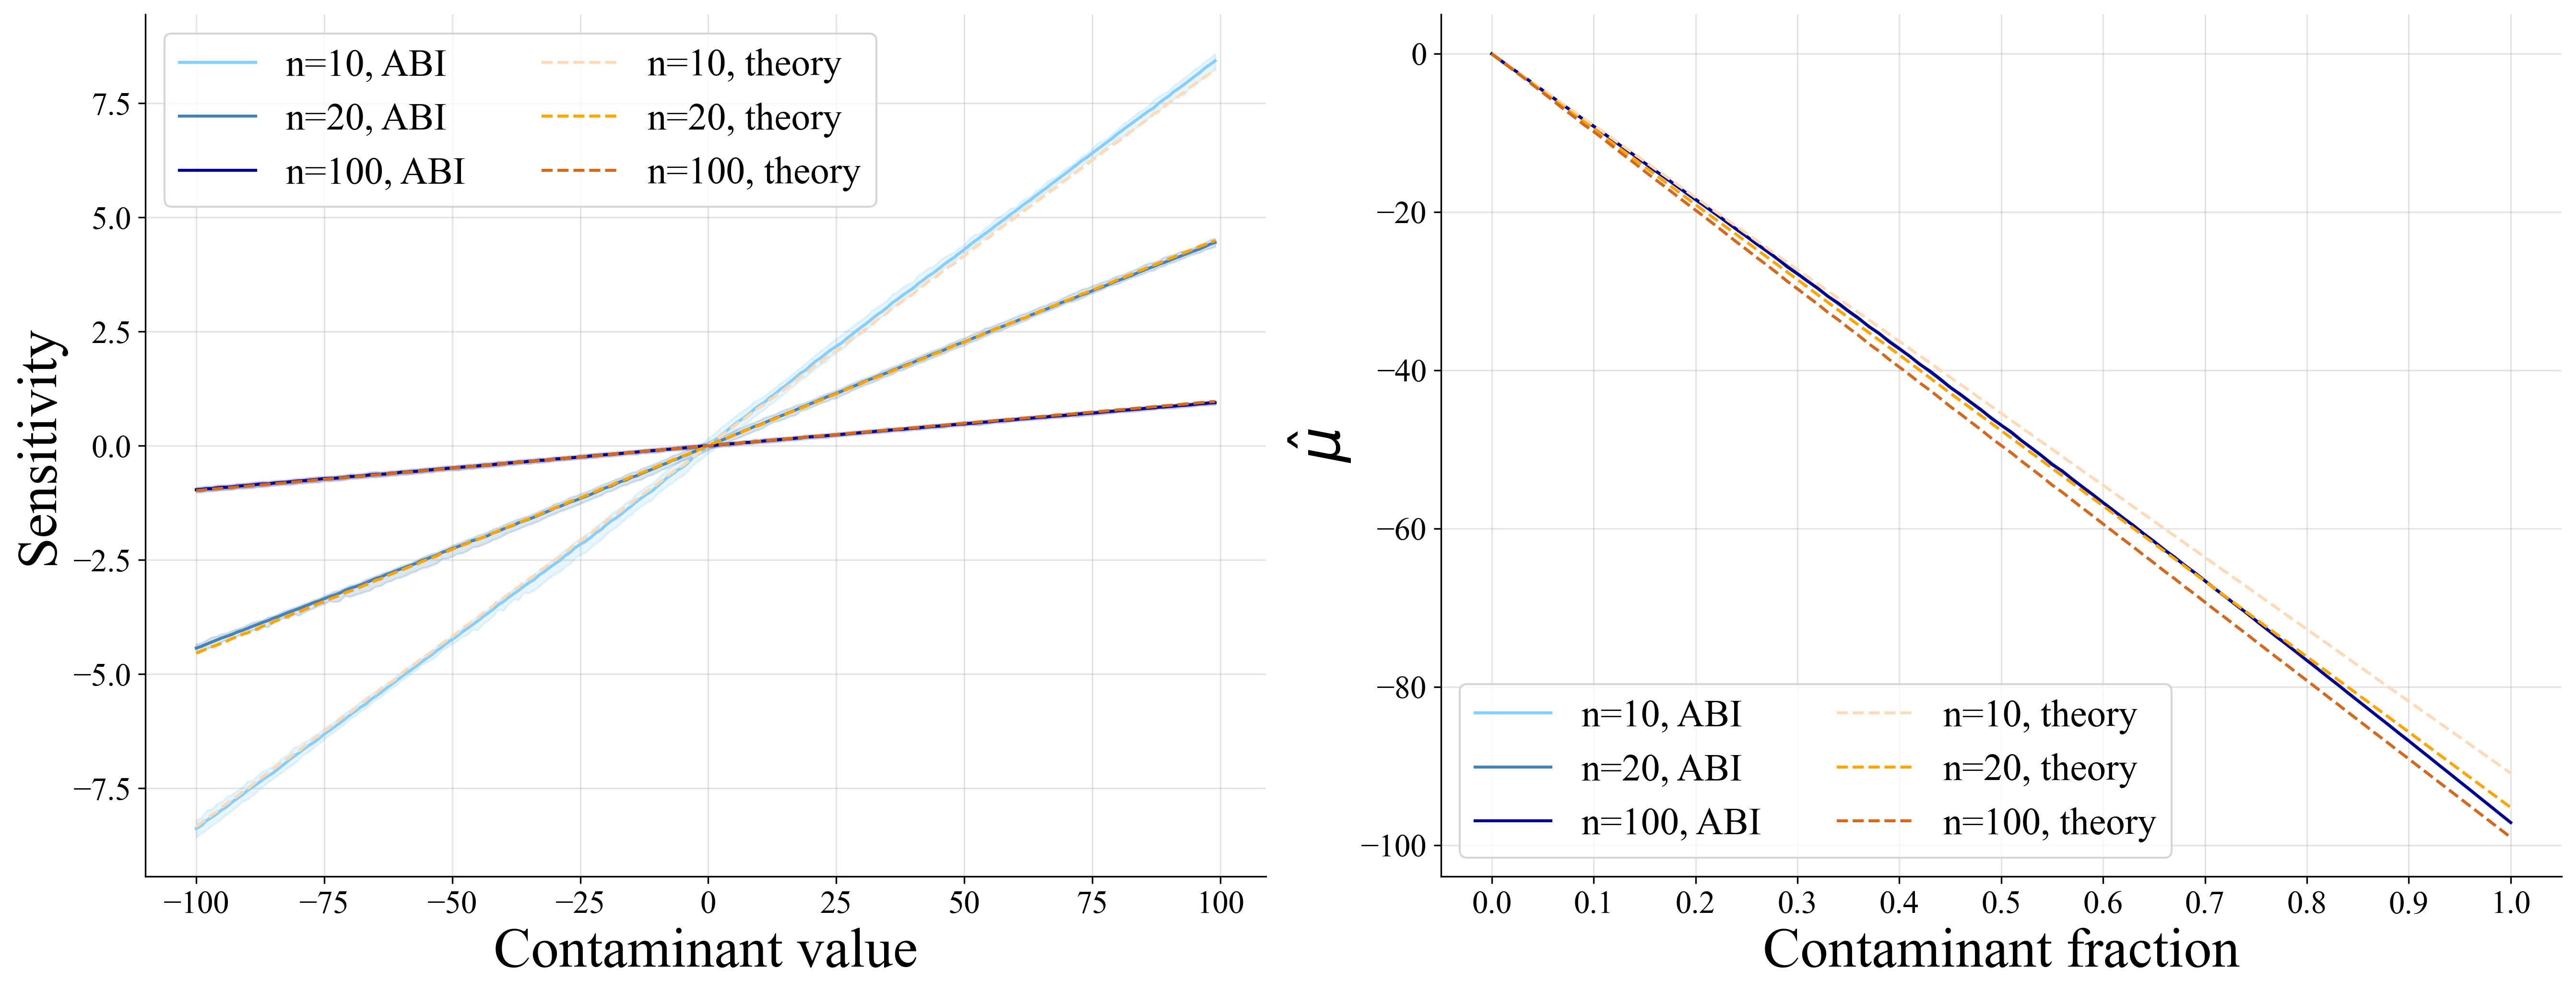

In [62]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'Times New Roman'

# Create side-by-side subplots
fig, axs = plt.subplots(1, 2, figsize=(18, 7), dpi=300)

### ----------- Panel (a): SSC -----------
ax = axs[0]

# Fill + line plots
ax.plot(xinfl, infl_10, color='lightskyblue', linestyle='-', label='n=10, ABI')
ax.fill_between(xinfl, infl_10_lower, infl_10_upper, color='lightskyblue', alpha=0.2)

ax.plot(xinfl, infl_20, color='steelblue', linestyle='-', label='n=20, ABI')
ax.fill_between(xinfl, infl_20_lower, infl_20_upper, color='steelblue', alpha=0.2)

ax.plot(xinfl, infl_100, color='darkblue', linestyle='-', label='n=100, ABI')
ax.fill_between(xinfl, infl_100_lower, infl_100_upper, color='darkblue', alpha=0.2)

ax.plot(xinfl, infl_theory_10, color='peachpuff', linestyle='--', label='n=10, theory')
ax.plot(xinfl, infl_theory_20, color='orange', linestyle='--', label='n=20, theory')
ax.plot(xinfl, infl_theory_100, color='chocolate', linestyle='--', label='n=100, theory')

# Labels, grid, styling
ax.set_xlabel('Contaminant value', fontsize=28)
ax.set_ylabel('Sensitivity', fontsize=28)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='grey', linestyle='-', alpha=0.2)
ax.legend(ncol=2, loc="upper left", frameon=True, fontsize=19)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Panel label
#ax.text(-0.12, 1.05, '(a)', transform=ax.transAxes, fontsize=30, fontweight='bold')

### ----------- Panel (b): BP -----------
ax = axs[1]

# Line plots
ax.plot(np.arange(0,1.1,0.1), bp_10, color='lightskyblue', label='n=10, ABI')
ax.plot(np.arange(0,1.05,0.05), bp_20, color='steelblue', label='n=20, ABI')
ax.plot(np.arange(0,1.01,0.01), bp_100, color='darkblue', label='n=100, ABI')

ax.plot(np.arange(0,1.1,0.1), bp_theory_10, color='peachpuff', linestyle='--', label='n=10, theory')
ax.plot(np.arange(0,1.05,0.05), bp_theory_20, color='orange', linestyle='--', label='n=20, theory')
ax.plot(np.arange(0,1.01,0.01), bp_theory_100, color='chocolate', linestyle='--', label='n=100, theory')

# Labels, grid, styling
ax.set_xlabel('Contaminant fraction', fontsize=28)
ax.set_ylabel(r'$\hat{\mu}$', fontsize=28)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(color='grey', linestyle='-', alpha=0.2)
ax.legend(ncol=2, loc="lower left", frameon=True, fontsize=19)
ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

# Panel label
#ax.text(-0.12, 1.05, '(b)', transform=ax.transAxes, fontsize=30, fontweight='bold')

### ----------- Save -----------
plt.tight_layout()
#plt.savefig("C:/Users/u0145642/OneDrive - KU Leuven/Desktop/submission-Robust ABI/revision/yw_2025_fig4.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Define robust estimators

## Plot normal and a t-distribution with different $\nu$

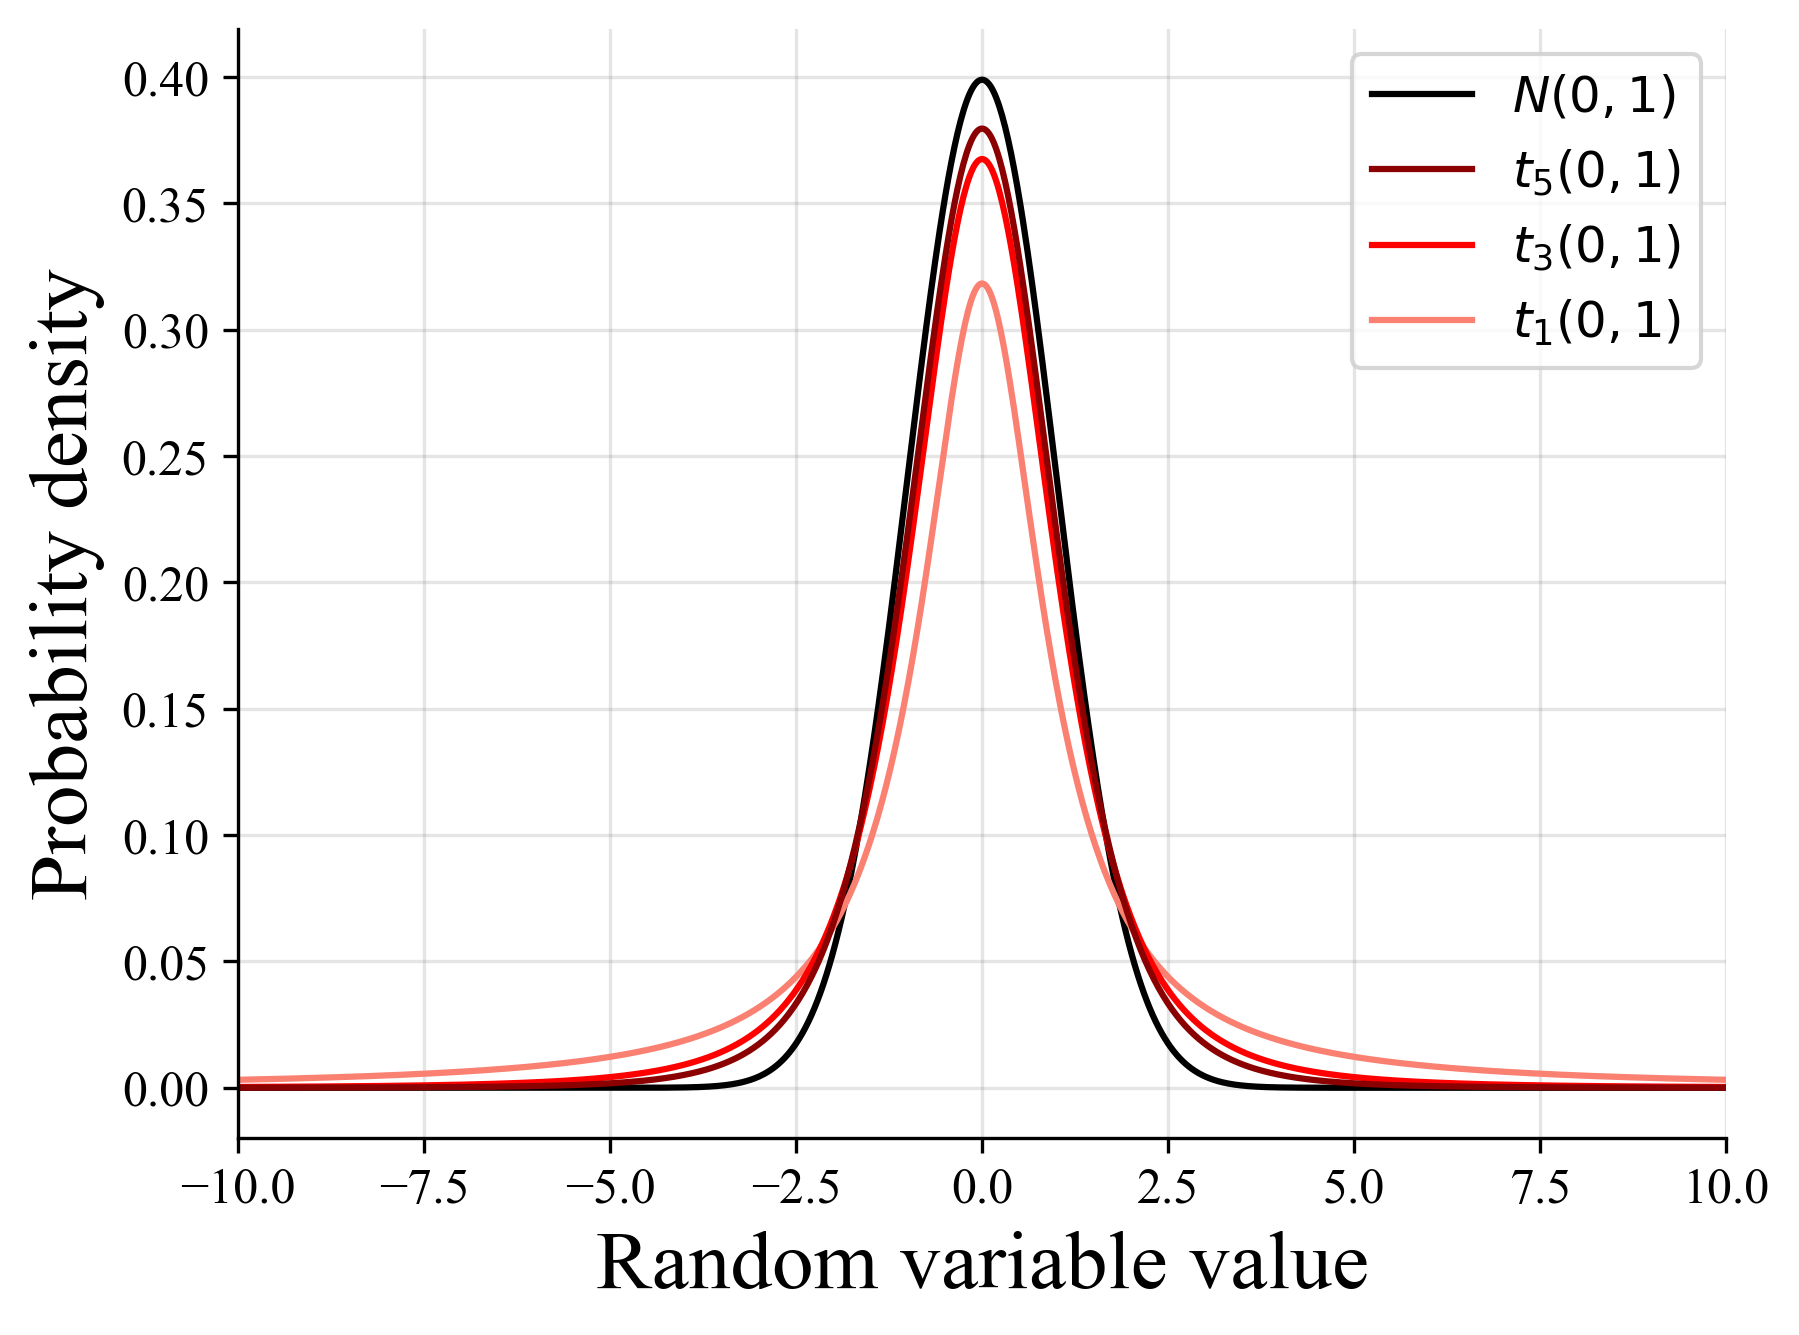

In [4]:
x = np.linspace(-10, 10, 1000)
normal = norm.pdf(x,loc=0,scale=1)
t_df1 = t.pdf(x,1)
t_df3 = t.pdf(x,3)
t_df5 = t.pdf(x,5)

plt.figure(dpi=300)
plt.rcParams['font.family'] = 'Times New Roman'
plt.plot(x, normal, color = 'black',label='Standard normal distribution')
plt.plot(x, t_df1, color = 'salmon', label='Standard t distribution, df=1')
plt.plot(x, t_df3, color = 'red', label='Standard t distribution, df=3')
plt.plot(x, t_df5, color = 'darkred', label='Standard t distribution, df=5')
plt.xlim(-10,10)
plt.ylabel('Probability density',size=20)
plt.xlabel('Random variable value',size=20)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


# Set grey grid
plt.grid(color='grey', linestyle='-',alpha=0.2)


plt.tick_params(axis='x', labelsize=12)
plt.tick_params(axis='y', labelsize=12)

plt.legend(loc='upper right', handles=[plt.Line2D([], [], color='black', label=r'$N(0,1)$'),
                                plt.Line2D([], [], color='darkred', label=r'$t_5(0,1)$'),
                                plt.Line2D([], [], color='red', label=r'$t_3(0,1)$'),
                                plt.Line2D([], [], color='salmon', label=r'$t_1(0,1)$')],fontsize=12)

## df=1

In [54]:
D=1
def prior_fun(D=D):
    return RNG.normal(size=D)

PARAM_NAMES = [
    r'$\mu$'
]

prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)


def likelihood_fun_df1(params, n_obs=RNG.integers(10,101)):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=1,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.1,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df1 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df1)
model_df1 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df1)

summary_net_df1 = bf.networks.DeepSet(summary_dim=2)
inference_net_df1 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)


amortizer_df1 = bf.amortizers.AmortizedPosterior(inference_net_df1, summary_net_df1)
trainer_df1 = bf.trainers.Trainer(amortizer=amortizer_df1, 
                                  generative_model=model_df1,
                                  checkpoint_path = checkpoint_path_df1
                                 )
#history = trainer_df1.train_online(epochs=10, iterations_per_epoch=4000, batch_size=32)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 18, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\df1\history_10.pkl.
INFO:root:Networks loaded from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\df1\ckpt-10
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


## df=3

In [55]:
RNG = np.random.default_rng(79)
import tensorflow as tf
D=1
def prior_fun(D=D):
    return RNG.normal(size=D)

PARAM_NAMES = [
    r'$\mu$'
]

prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)


def likelihood_fun_df3(params, n_obs=RNG.integers(10,101)):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=3,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.1,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y



simulator_df3 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df3)
model_df3 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df3)

summary_net_df3 = bf.networks.DeepSet(summary_dim=2)
inference_net_df3 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": None}
)

amortizer_df3 = bf.amortizers.AmortizedPosterior(inference_net_df3, summary_net_df3)
trainer_df3 = bf.trainers.Trainer(amortizer=amortizer_df3, generative_model=model_df3, checkpoint_path = checkpoint_path_df3)
#history = trainer_df3.train_online(epochs=10, iterations_per_epoch=4000, batch_size=32)


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 19, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\df3\history_10.pkl.
INFO:root:Networks loaded from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\df3\ckpt-10
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


## df=5

In [56]:
RNG = np.random.default_rng(17)
D=1
def prior_fun(D=D):
    return RNG.normal(size=D)

PARAM_NAMES = [
    r'$\mu$'
]

prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)


def likelihood_fun_df5(params, n_obs=RNG.integers(10,101)):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=5,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.1,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df5 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df5)
model_df5 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df5)

summary_net_df5 = bf.networks.DeepSet(summary_dim=2)
inference_net_df5 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": None},
)

amortizer_df5 = bf.amortizers.AmortizedPosterior(inference_net_df5, summary_net_df5)
trainer_df5 = bf.trainers.Trainer(amortizer=amortizer_df5, generative_model=model_df5, checkpoint_path =checkpoint_path_df5)
#history = trainer_df5.train_online(epochs=10, iterations_per_epoch=4000, batch_size=32)


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 77, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\df5\history_10.pkl.
INFO:root:Networks loaded from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\df5\ckpt-10
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.


## Parameter recovery

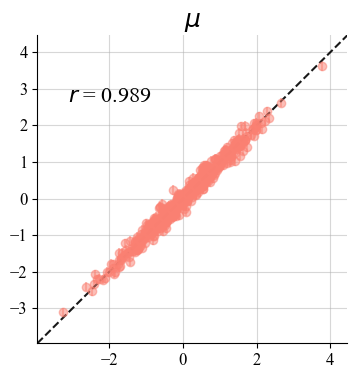

In [15]:
test_sims = trainer_df1.configurator(model(500))
post_samples = amortizer_df1.sample(test_sims, n_samples=1000)
plt.rcParams['font.family'] = 'Times New Roman'
try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='salmon',add_r2=False)
except Exception as e:
    # Suppress the error and continue execution
    pass

plt.savefig(root_dir/"plots/parameter_recovery_location_parameter_robust_df1.pdf", format="pdf", bbox_inches="tight")


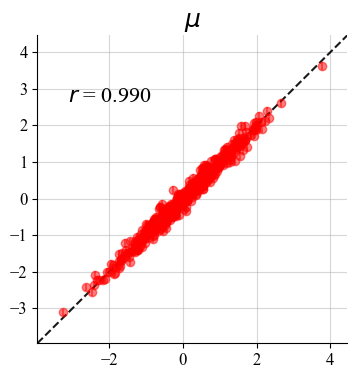

In [16]:
post_samples = amortizer_df3.sample(test_sims, n_samples=1000)
plt.rcParams['font.family'] = 'Times New Roman'
try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='red',add_r2=False)
except Exception as e:
    # Suppress the error and continue execution
    pass

plt.savefig(root_dir/"plots/parameter recovery location parameter robust df3.pdf", format="pdf", bbox_inches="tight")


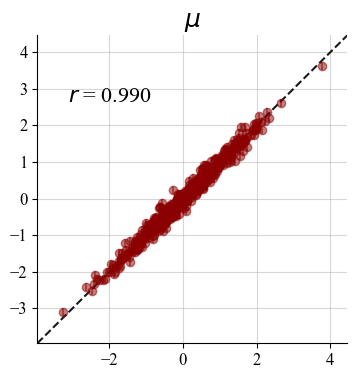

In [17]:
post_samples = amortizer_df5.sample(test_sims, n_samples=1000)
plt.rcParams['font.family'] = 'Times New Roman'
try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='darkred',add_r2=False)
except Exception as e:
    # Suppress the error and continue execution
    pass
plt.savefig(root_dir/"plots/parameter_recovery_location_parameter_robust_df5.pdf", format="pdf", bbox_inches="tight")


## SSC

In [56]:
#define the stylized sensitivity curve
def compute_ssc_robust(xinfl, amortizer, batch_size, trainer, sample_size, n_samples=150):
    nrx=len(xinfl)
    infl = np.zeros(shape=nrx)
    infl_upper = np.zeros(shape=nrx)
    infl_lower = np.zeros(shape=nrx)
    
    for j in tqdm(range(nrx), desc="Progress", leave=False):
        sim_data = obtain_quantile(batch_size, sample_size)
        sim_data_orig = copy.deepcopy(sim_data)
        x_c = xinfl[j] * np.ones((batch_size, 1 ,1))
        sim_data['sim_data'] = np.concatenate((sim_data["sim_data"], x_c), axis = 1)
    
        #inference from BF
        post_samples = amortizer.sample(trainer.configurator(sim_data), n_samples=n_samples)
        post_samples_orig = amortizer.sample(trainer.configurator(sim_data_orig), n_samples=n_samples)
        avgpost = np.mean(post_samples, axis = 1)
        avgpost_orig = np.mean(post_samples_orig, axis = 1)
        diff = avgpost - avgpost_orig
    
        
        infl[j] = np.mean(diff)
        infl_upper[j] = np.percentile(diff, 97.5)
        infl_lower[j] = np.percentile(diff, 2.5)
        
    
    return infl, infl_upper, infl_lower


In [2]:
# Compute the EIF
xinfl = np.arange(-100, 100, 1)
infl_df1, infl_df1_upper, infl_df1_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df1, trainer = trainer_df1, sample_size = 20, batch_size = 100)

infl_df3, infl_df3_upper, infl_df3_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df3, trainer = trainer_df3, sample_size = 20, batch_size = 100)

infl_df5, infl_df5_upper, infl_df5_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df5, trainer = trainer_df5, sample_size = 20, batch_size = 100)


## Tukey's biweight function

In [21]:
## Generate residuals (deviations) for plotting
## Zoom in to a narrower range between -25 to 25
x_vals = np.linspace(-25, 25, 50)
#infl_df1_tukey = compute_eif_robust(xinfl = x_vals, model = model_20, amortizer = amortizer_df1, trainer = trainer_df1)

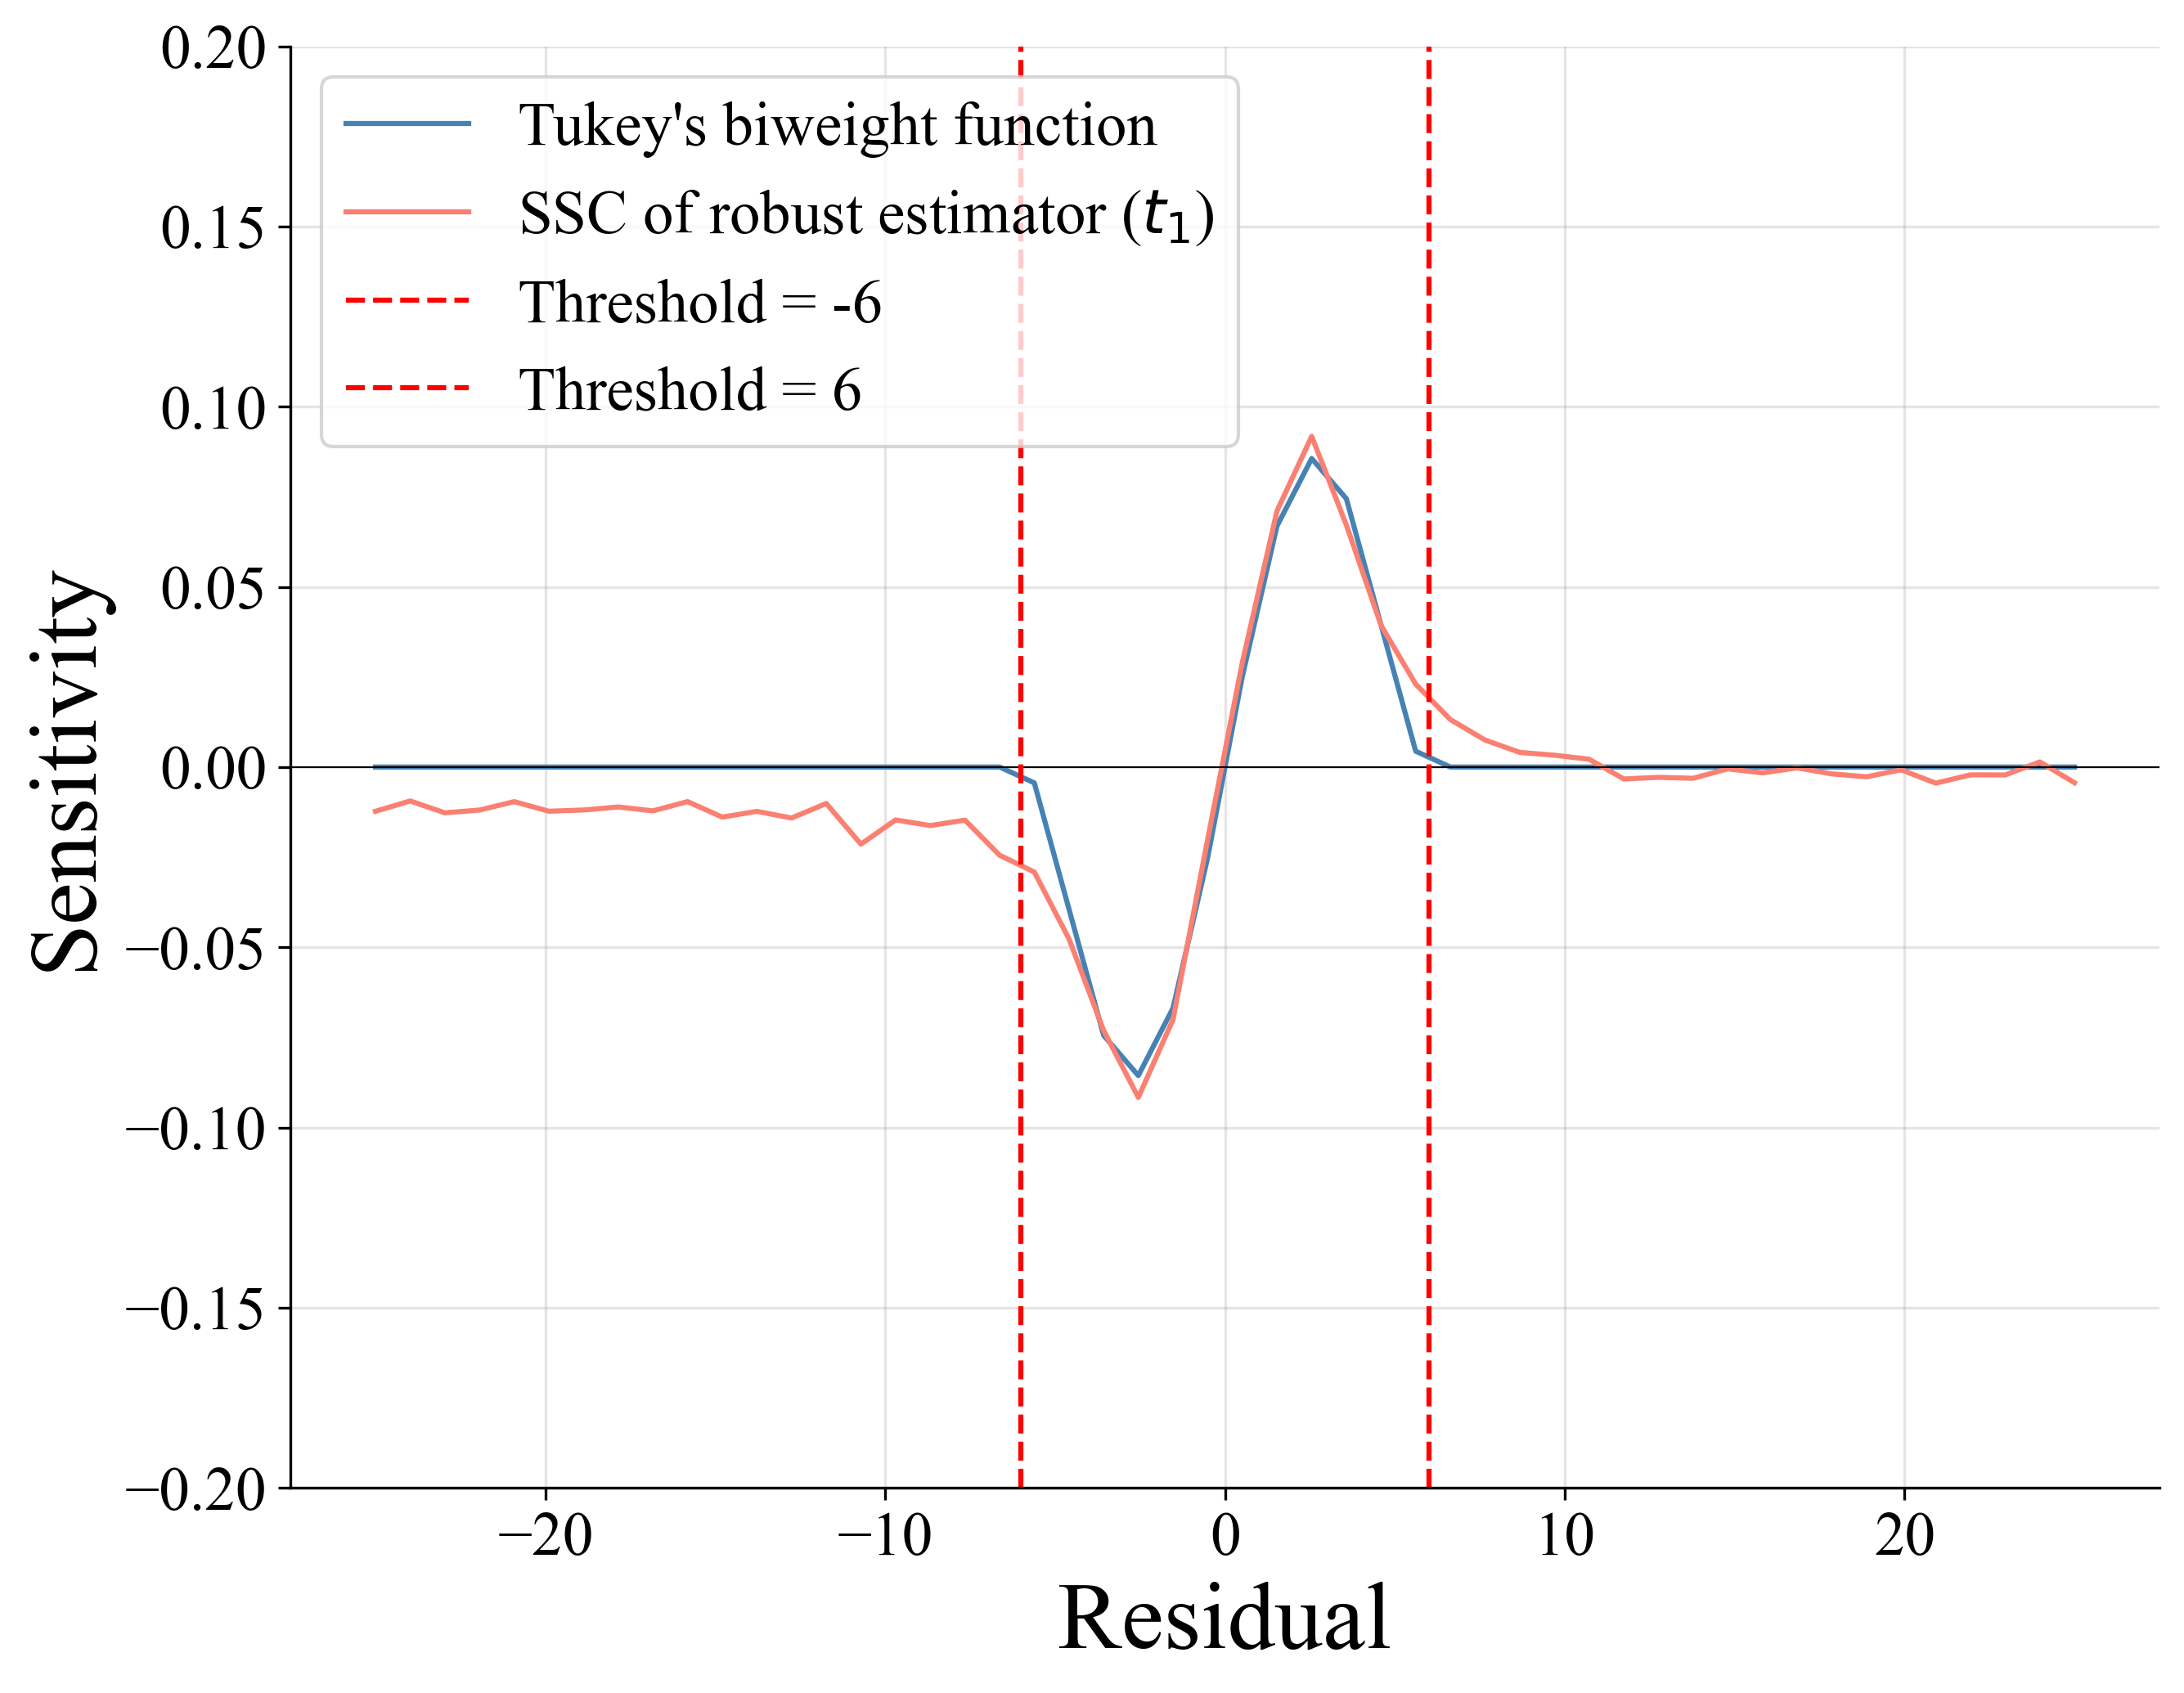

In [58]:
%store -r infl_df1_tukey

def tukey_biweight_influence_function(x, c):
    """
    Tukey's biweight influence function.

    Parameters:
    x : array-like
        The residuals or deviations from the center (location parameter).
    k : float
        The tuning constant that determines how far outliers are ignored.

    Returns:
    influence : array-like
        The influence function values for each residual.
    """
    influence = np.zeros_like(x)
    mask = np.abs(x) <= k
    influence[mask] = (x[mask] * (1 - (x[mask] / k)**2)**2)/20
    return influence

# Set the tuning constant c
k = 6  # Typical choice for robust estimation

# Compute the influence function values
influence_vals = tukey_biweight_influence_function(x_vals, k)

# Plotting the Tukey biweight influence function
plt.figure(figsize=(9, 7),dpi=300)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)


# Set grey grid
plt.grid(color='grey', linestyle='-',alpha=0.2)
plt.rcParams['font.family'] = 'Times New Roman'
plt.ylim(-0.2,0.2)
plt.plot(x_vals, influence_vals, label=r"Tukey's biweight function", color='steelblue')
plt.plot(x_vals, infl_df1_tukey, label=r"SSC of robust estimator ($t_1$)", color='salmon')
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)

plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(-k, color='red', linestyle='--', label=f'Threshold = -{k}')
plt.axvline(k, color='red', linestyle='--', label=f'Threshold = {k}')
plt.xlabel('Residual', fontsize=28)
plt.ylabel('Sensitivity', fontsize=28)
plt.legend(fontsize=18)
plt.tight_layout()

#plt.savefig(root_dir/"plots/Tukey_biweight_function.pdf", format="pdf", bbox_inches="tight")
plt.show()

## Breakdown point

In [37]:
##simulate data with 3 as as the true mean
D=1
def new_prior_fun(D=D):
    return RNG.normal(loc=3,size=D)

PARAM_NAMES = [
    r'$\mu$'
]

new_prior = bf.simulation.Prior(prior_fun=new_prior_fun, param_names=PARAM_NAMES)

new_model_20 = bf.simulation.GenerativeModel(prior=new_prior, simulator=simulator_20)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 20, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.


In [38]:
#Define BP
def compute_bp_robust(ninfl, model, trainer, amortizer, batch_size=500,n_samples=150):
    nrx=len(ninfl)
    bp = np.zeros(shape=(nrx, 1))
    
    for j in tqdm(range(nrx), desc="Progress", leave=False):
        sim_data = model(batch_size=batch_size)
        sim_data['sim_data'][:,0:ninfl[j]] = -100
        post_samples = amortizer.sample(trainer.configurator(sim_data), n_samples=n_samples)
        bp[j] = np.mean(np.mean(post_samples, axis=1))
        del sim_data, post_samples
        gc.collect()  # Force garbage collection
    
    return bp

In [39]:
#Compute BP
ninfl = np.arange(0,21,1)
bp_df1 = compute_bp_robust(ninfl=ninfl, model = new_model_20, trainer = trainer_df1, amortizer = amortizer_df1)
bp_df3 = compute_bp_robust(ninfl=ninfl, model = new_model_20, trainer = trainer_df3, amortizer = amortizer_df3)
bp_df5 = compute_bp_robust(ninfl=ninfl, model = new_model_20, trainer = trainer_df5, amortizer = amortizer_df5)

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

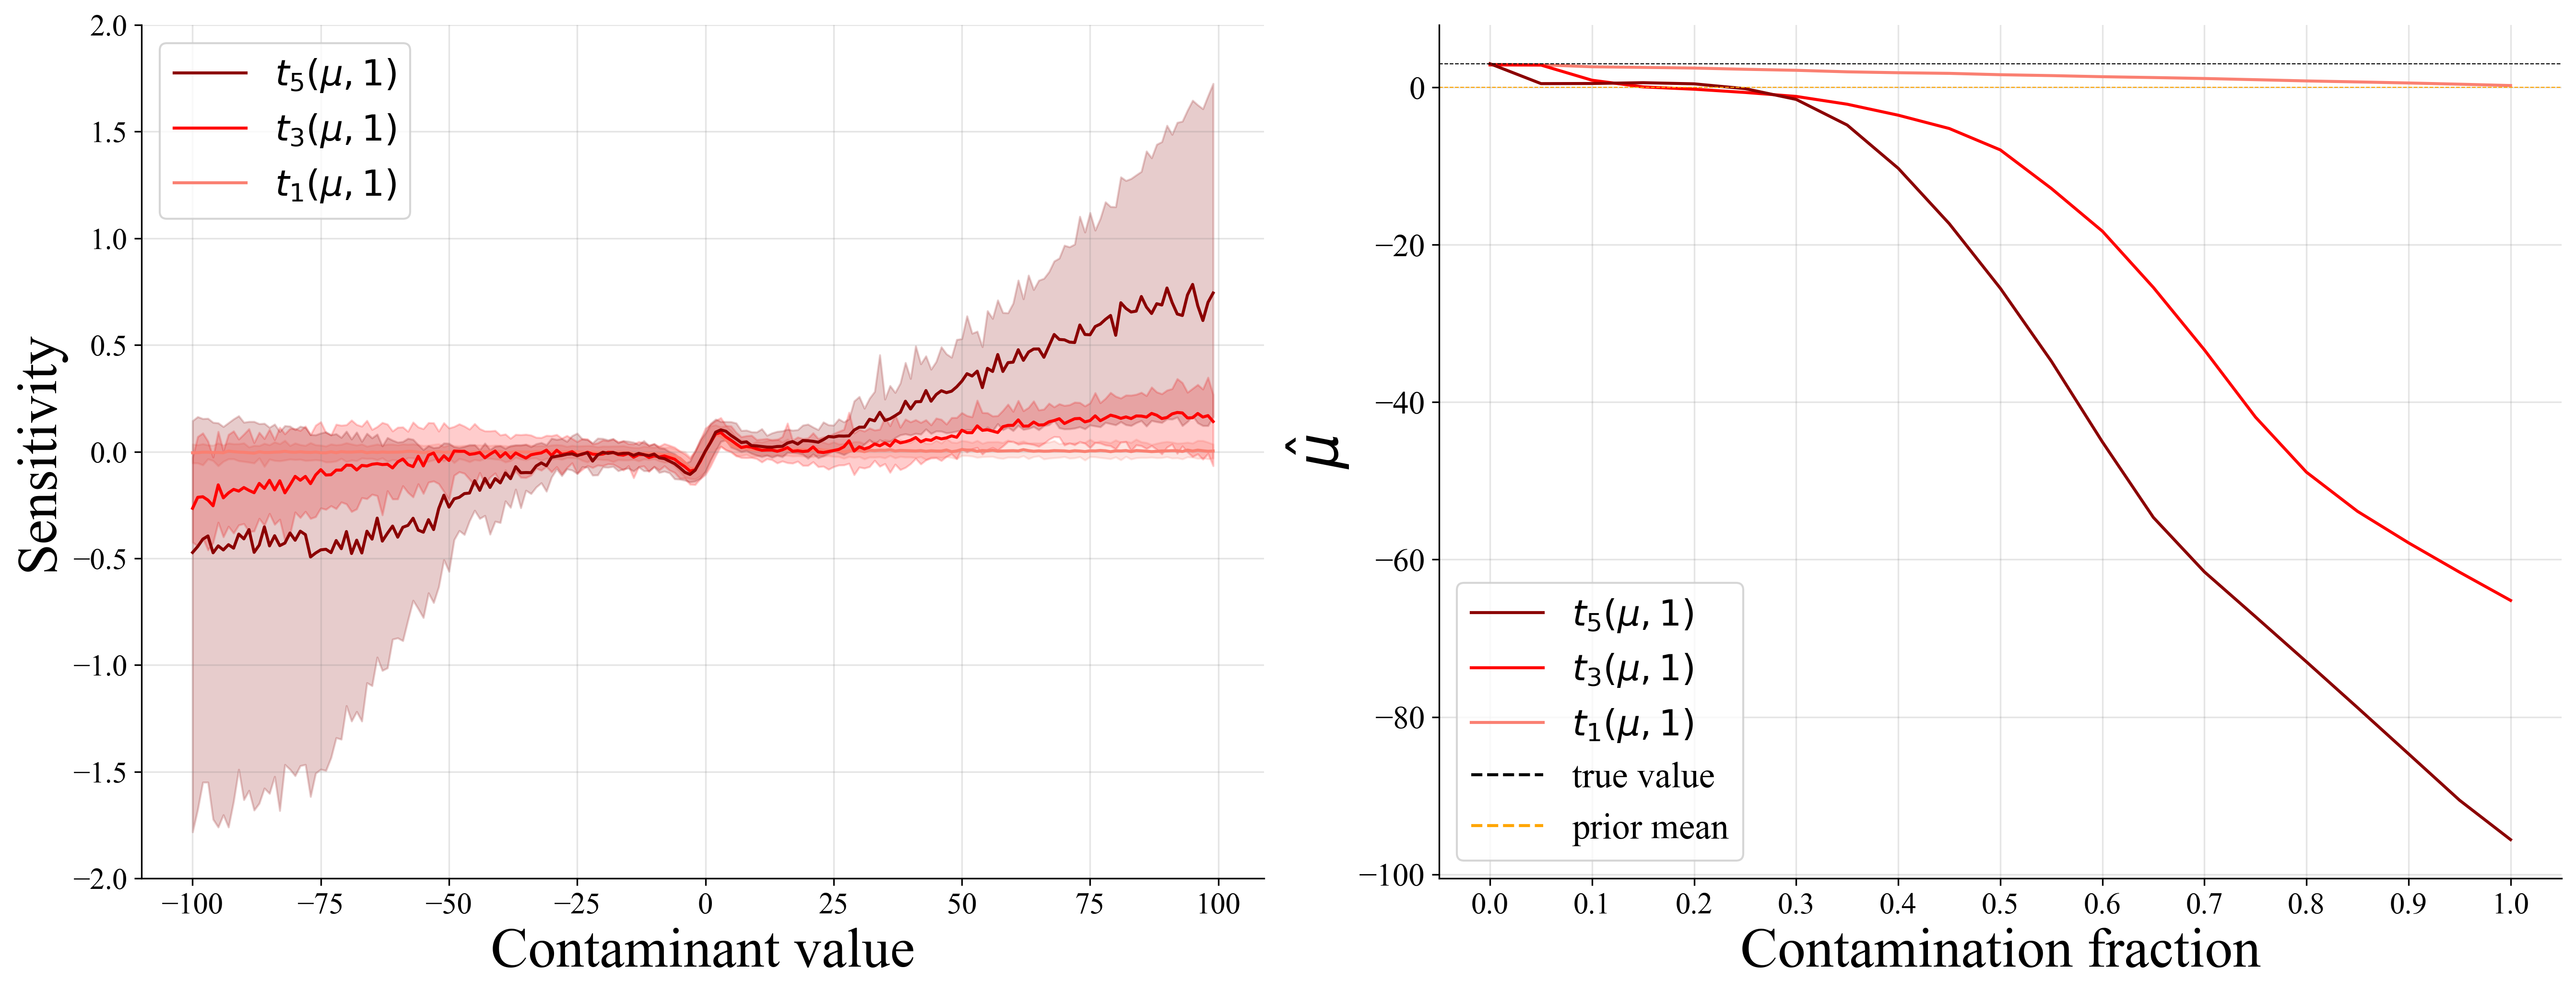

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming infl_df1, infl_df1_upper, infl_df1_lower, etc. are already loaded

xinfl = np.arange(-100, 100, 1)
x_bp = np.arange(0, 1.05, 0.05)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=300)  # 1 row, 2 cols

plt.rcParams['font.family'] = 'Times New Roman'

# --- Left plot: EIF ---
ax1.plot(xinfl, infl_df1, color='salmon')
ax1.fill_between(xinfl, infl_df1_lower, infl_df1_upper, color='salmon', alpha=0.2)

ax1.plot(xinfl, infl_df3, color='red')
ax1.fill_between(xinfl, infl_df3_lower, infl_df3_upper, color='red', alpha=0.2)

ax1.plot(xinfl, infl_df5, color='darkred')
ax1.fill_between(xinfl, infl_df5_lower, infl_df5_upper, color='darkred', alpha=0.2)

ax1.set_xlabel('Contaminant value', fontsize=28)
ax1.set_ylabel("Sensitivity", fontsize=28)
ax1.set_ylim(-2, 2)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(color='grey', linestyle='-', alpha=0.2)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)

ax1.legend(loc='upper left', handles=[
    plt.Line2D([], [], color='darkred', label=r'$t_5(\mu,1)$'),
    plt.Line2D([], [], color='red', label=r'$t_3(\mu,1)$'),
    plt.Line2D([], [], color='salmon', label=r'$t_1(\mu,1)$')],
    fontsize=18
)

# --- Right plot: BP ---
ax2.plot(x_bp, bp_df1, color='salmon')
ax2.plot(x_bp, bp_df3, color='red')
ax2.plot(x_bp, bp_df5, color='darkred')

ax2.set_xlabel('Contamination fraction', fontsize=28)
ax2.set_ylabel(r'$\hat{\mu}$', fontsize=28)
ax2.set_xticks(np.arange(0, 1.1, 0.1))

ax2.axhline(0, color='orange', linestyle='--', linewidth=0.5)
ax2.axhline(3, color='black', linestyle='--', linewidth=0.5)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(color='grey', linestyle='-', alpha=0.2)

ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=16)

ax2.legend(loc='lower left', handles=[
    plt.Line2D([], [], color='darkred', label=r'$t_5(\mu,1)$'),
    plt.Line2D([], [], color='red', label=r'$t_3(\mu,1)$'),
    plt.Line2D([], [], color='salmon', label=r'$t_1(\mu,1)$'),
    plt.Line2D([], [], color='black', linestyle='--', label=r'true value'),
    plt.Line2D([], [], color='orange', linestyle='--', label=r'prior mean')],
    fontsize=18
)

plt.tight_layout()  # Adjust spacing to prevent overlap
#plt.savefig("C:/Users/u0145642/OneDrive - KU Leuven/Desktop/submission-Robust ABI/revision/yw_2025_fig6.pdf", format="pdf", bbox_inches="tight")
plt.show()


# The cost of robustness

In [21]:
D=1
def prior_fun(D=D):
    return RNG.normal(size=D)

PARAM_NAMES = [
    r'$\mu$'
]

prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)



#default scale is 1
def likelihood_fun_cost(params,n_obs = 20):
    return RNG.normal(loc=params, size=(n_obs, params.shape[0]))

simulator_cost = bf.simulation.Simulator(simulator_fun=likelihood_fun_cost)

model_cost = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_cost)

summary_net = bf.networks.DeepSet(summary_dim=2)

inference_net = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

amortizer_cost = bf.amortizers.AmortizedPosterior(inference_net, summary_net)

trainer_cost = bf.trainers.Trainer(amortizer=amortizer_cost, 
                              generative_model=model_cost,
                             checkpoint_path = checkpoint_path_standard_cost)
#history = trainer_cost.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)

def likelihood_fun_df1_cost(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=1,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.1,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df1_cost = bf.simulation.Simulator(simulator_fun=likelihood_fun_df1_cost)
model_df1_cost = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df1_cost)

summary_net_df1 = bf.networks.DeepSet(summary_dim=2)
inference_net_df1 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)


amortizer_df1_cost = bf.amortizers.AmortizedPosterior(inference_net_df1, summary_net_df1)
trainer_df1_cost = bf.trainers.Trainer(amortizer=amortizer_df1_cost, 
                                  generative_model=model_df1_cost,
                                  checkpoint_path = checkpoint_path_df1_cost
                                 )
#history = trainer_df1_cost.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)

def likelihood_fun_df3_cost(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=3,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.1,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df3_cost = bf.simulation.Simulator(simulator_fun=likelihood_fun_df3_cost)
model_df3_cost = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df3_cost)

summary_net_df3 = bf.networks.DeepSet(summary_dim=2)
inference_net_df3 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)

amortizer_df3_cost = bf.amortizers.AmortizedPosterior(inference_net_df3, summary_net_df3)
trainer_df3_cost = bf.trainers.Trainer(amortizer=amortizer_df3_cost, 
                                  generative_model=model_df3_cost, 
                                  checkpoint_path = checkpoint_path_df3_cost)
#history = trainer_df3_cost.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)

def likelihood_fun_df5_cost(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=5,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.1,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df5_cost = bf.simulation.Simulator(simulator_fun=likelihood_fun_df5_cost)
model_df5_cost = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df5_cost)

summary_net_df5 = bf.networks.DeepSet(summary_dim=2)
inference_net_df5 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False},
)

amortizer_df5_cost = bf.amortizers.AmortizedPosterior(inference_net_df5, summary_net_df5)
trainer_df5_cost = bf.trainers.Trainer(amortizer=amortizer_df5_cost, 
                                  generative_model=model_df5_cost, 
                                  checkpoint_path =checkpoint_path_df5_cost)
#history = trainer_df5_cost.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)

INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 20, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\cost of robustness\standard\history_10.pkl.
INFO:root:Networks loaded from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\cost of robustness\standard\ckpt-10
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.
INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of par

## Mean absolute error and posterior variance

In [56]:
test_sims = model(batch_size=20000)
def cost(amortizer, n_samples=100):
    post_samples = amortizer.sample(trainer.configurator(test_sims), n_samples=n_samples)
    post_samples_mean = np.mean(post_samples,axis=1)
    true_parameters =  test_sims['prior_draws']
    MAE = np.mean(np.abs(true_parameters-post_samples_mean))
    VAR = np.mean(np.var(post_samples,axis=1))
    
    return MAE, VAR

In [57]:
MAE_normal_standard, VAR_normal_standard = cost(amortizer=amortizer_cost)
MAE_normal_df1, VAR_normal_df1 = cost(amortizer=amortizer_df1_cost)
MAE_normal_df3, VAR_normal_df3 = cost(amortizer=amortizer_df3_cost)
MAE_normal_df5, VAR_normal_df5 = cost(amortizer=amortizer_df5_cost)

In [58]:
print(f'ErrorRatio t_1', np.round(MAE_normal_standard/ MAE_normal_df1, 3))
print(f'ErrorRatio t_3', np.round(MAE_normal_standard/ MAE_normal_df3, 3))
print(f'ErrorRatio t_5', np.round(MAE_normal_standard/ MAE_normal_df5, 3))

print(f'VarRatio t_1', np.round(VAR_normal_standard/ VAR_normal_df1, 3))
print(f'VarRatio t_3', np.round(VAR_normal_standard/ VAR_normal_df3, 3))
print(f'VarRatio t_5', np.round(VAR_normal_standard/ VAR_normal_df5, 3))

ErrorRatio t_1 0.998
ErrorRatio t_3 0.997
ErrorRatio t_5 0.999
VarRatio t_1 0.908
VarRatio t_3 0.945
VarRatio t_5 0.969


## Manipulate pi

In [46]:
D=1
def prior_fun(D=D):
    return RNG.normal(size=D)

PARAM_NAMES = [
    r'$\mu$'
]

prior = bf.simulation.Prior(prior_fun=prior_fun, param_names=PARAM_NAMES)


def likelihood_fun_df1_001(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=1,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.01,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df1_001 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df1_001)
model_df1_001 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df1_001)

summary_net_df1_001 = bf.networks.DeepSet(summary_dim=2)
inference_net_df1_001 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)


amortizer_df1_001 = bf.amortizers.AmortizedPosterior(inference_net_df1_001, summary_net_df1_001)
trainer_df1_001 = bf.trainers.Trainer(amortizer=amortizer_df1_001, 
                                  generative_model=model_df1_001,
                                  checkpoint_path = checkpoint_path_df1_001
                                 )
#history = trainer_df1_001.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)


def likelihood_fun_df1_005(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=1,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.05,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df1_005 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df1_005)
model_df1_005 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df1_005)

summary_net_df1_005 = bf.networks.DeepSet(summary_dim=2)
inference_net_df1_005 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)


amortizer_df1_005 = bf.amortizers.AmortizedPosterior(inference_net_df1_005, summary_net_df1_005)
trainer_df1_005 = bf.trainers.Trainer(amortizer=amortizer_df1_005, 
                                  generative_model=model_df1_005,
                                  checkpoint_path = checkpoint_path_df1_005
                                 )
#history = trainer_df1_005.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)

def likelihood_fun_df1_010(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=1,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.10,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df1_010 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df1_010)
model_df1_010 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df1_010)

summary_net_df1_010 = bf.networks.DeepSet(summary_dim=2)
inference_net_df1_010 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)


amortizer_df1_010 = bf.amortizers.AmortizedPosterior(inference_net_df1_010, summary_net_df1_010)
trainer_df1_010 = bf.trainers.Trainer(amortizer=amortizer_df1_010, 
                                  generative_model=model_df1_010,
                                  checkpoint_path = checkpoint_path_df1_010
                                 )
#history = trainer_df1_010.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)

def likelihood_fun_df1_020(params, n_obs=20):
    NN=RNG.normal(loc=params,size=(n_obs, params.shape[0]))
    CC=RNG.standard_t(df=1,size=(n_obs, params.shape[0]))+params
    X=RNG.binomial(n=1,p=.20,size=(n_obs, params.shape[0]))
    Y = (1-X)*NN + (X)*CC
    return Y

simulator_df1_020 = bf.simulation.Simulator(simulator_fun=likelihood_fun_df1_020)
model_df1_020 = bf.simulation.GenerativeModel(prior=prior, simulator=simulator_df1_020)

summary_net_df1_020 = bf.networks.DeepSet(summary_dim=2)
inference_net_df1_020 = bf.networks.InvertibleNetwork(
    num_params=D,
    num_coupling_layers=2,
    coupling_settings={"dense_args": dict(kernel_regularizer=None), "dropout": False}
)


amortizer_df1_020 = bf.amortizers.AmortizedPosterior(inference_net_df1_020, summary_net_df1_020)
trainer_df1_020 = bf.trainers.Trainer(amortizer=amortizer_df1_020, 
                                  generative_model=model_df1_020,
                                  checkpoint_path = checkpoint_path_df1_020
                                 )
#history = trainer_df1_020.train_online(epochs=10, iterations_per_epoch=2000, batch_size=32)


INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Shape of parameter batch after 2 pilot simulations: (batch_size = 2, 1)
INFO:root:Shape of simulation batch after 2 pilot simulations: (batch_size = 2, 20, 1)
INFO:root:No optional prior non-batchable context provided.
INFO:root:No optional prior batchable context provided.
INFO:root:No optional simulation non-batchable context provided.
INFO:root:No optional simulation batchable context provided.
INFO:root:Loaded loss history from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\contamination probablity\pi=0.01\history_10.pkl.
INFO:root:Networks loaded from C:\Users\u0145642\OneDrive - KU Leuven\Desktop\Robust amortized Bayesian inference\2 toy example\networks\contamination probablity\pi=0.01\ckpt-10
INFO:root:Performing a consistency check with provided components...
INFO:root:Done.
INFO:root:Performing 2 pilot runs with the anonymous model...
INFO:root:Sh

## SSC

In [4]:
# Compute the EIF
xinfl = np.arange(-100, 100, 1)
infl_df1_001, infl_df1_001_upper, infl_df1_001_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df1_001, trainer = trainer_df1_001, sample_size = 20, batch_size = 100)

infl_df1_005, infl_df1_005_upper, infl_df1_005_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df1_005, trainer = trainer_df1_005, sample_size = 20, batch_size = 100)

infl_df1_010, infl_df1_010_upper, infl_df1_010_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df1_010, trainer = trainer_df1_010, sample_size = 20, batch_size = 100)

infl_df1_020, infl_df1_020_upper, infl_df1_020_lower = compute_ssc_robust(xinfl = xinfl, amortizer = amortizer_df1_020, trainer = trainer_df1_020, sample_size = 20, batch_size = 100)


## Breakdown point

In [47]:
#compute BP
ninfl = np.arange(0,21,1)
bp_df1_001 = compute_bp_robust(ninfl = ninfl, trainer = trainer_df1_001, model=new_model_20, amortizer=amortizer_df1_001)
bp_df1_005 = compute_bp_robust(ninfl = ninfl, trainer = trainer_df1_005, model=new_model_20, amortizer=amortizer_df1_005)
bp_df1_010 = compute_bp_robust(ninfl = ninfl, trainer = trainer_df1_010, model=new_model_20, amortizer=amortizer_df1_010)
bp_df1_020 = compute_bp_robust(ninfl = ninfl, trainer = trainer_df1_020, model=new_model_20, amortizer=amortizer_df1_020)

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

Progress:   0%|          | 0/21 [00:00<?, ?it/s]

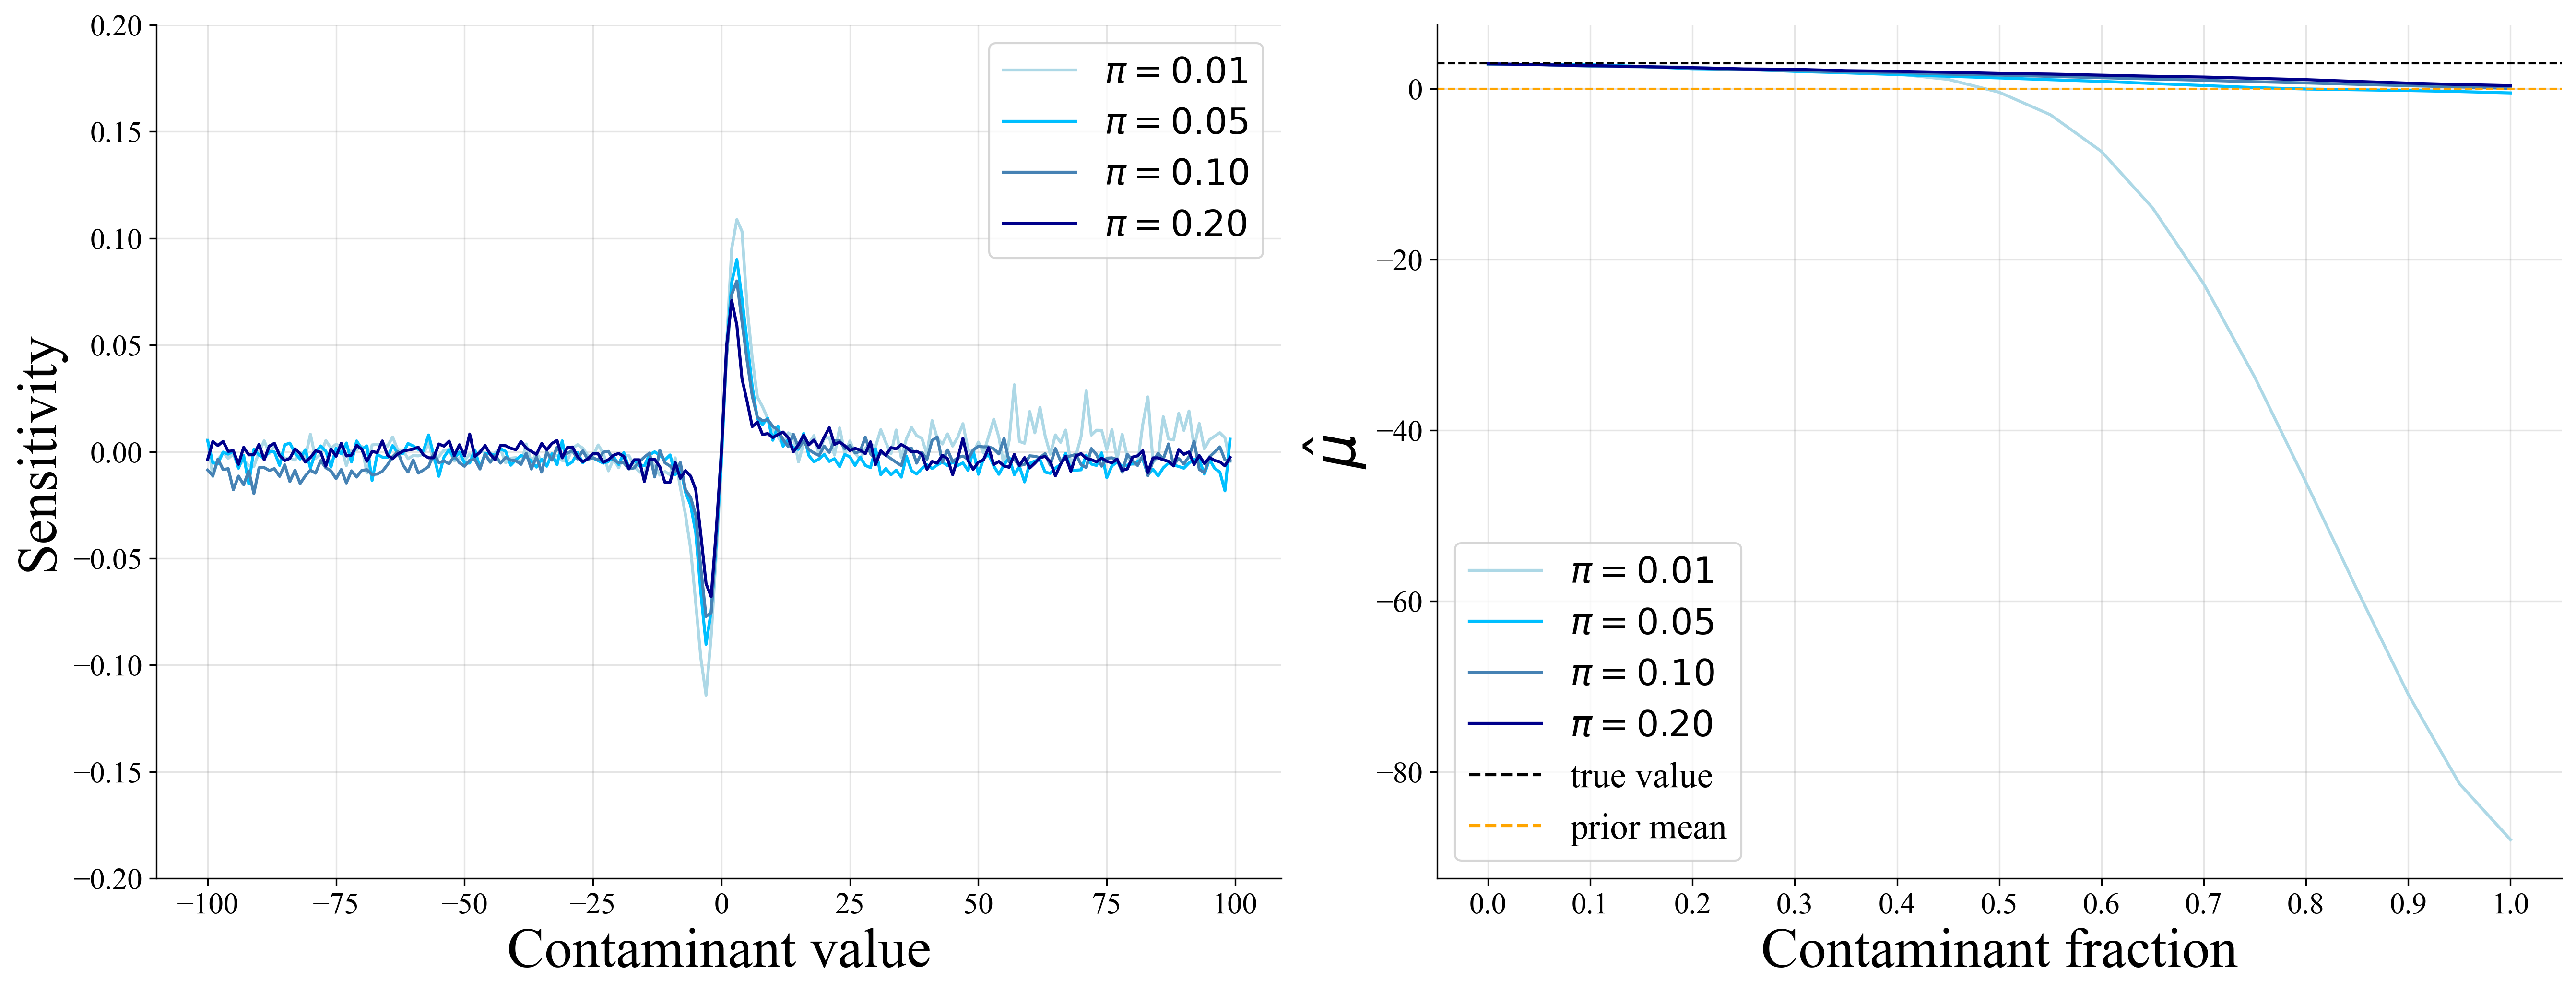

In [71]:
plt.rcParams['font.family'] = 'Times New Roman'
xinfl = np.arange(-100, 100, 1)
# Create the figure and two axes side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), dpi=300)

# ==== LEFT PLOT (EIF) ====
ax1.plot(xinfl, infl_df1_001, color='lightblue')
ax1.plot(xinfl, infl_df1_005, color='deepskyblue')
ax1.plot(xinfl, infl_df1_010, color='steelblue')
ax1.plot(xinfl, infl_df1_020, color='darkblue')

ax1.set_xlabel('Contaminant value', fontsize=28)
ax1.set_ylabel("Sensitivity", fontsize=28)
ax1.set_ylim(-0.2, 0.2)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(color='grey', linestyle='-', alpha=0.2)
ax1.tick_params(axis='x', labelsize=15)
ax1.tick_params(axis='y', labelsize=15)

ax1.legend(loc='best', handles=[
    plt.Line2D([], [], color='lightblue', label=r'$\pi=0.01$'),
    plt.Line2D([], [], color='deepskyblue', label=r'$\pi=0.05$'),
    plt.Line2D([], [], color='steelblue', label=r'$\pi=0.10$'),
    plt.Line2D([], [], color='darkblue', label=r'$\pi=0.20$')],
    fontsize=18)

# ==== RIGHT PLOT (BP) ====
x_bp = np.arange(0, 1.05, 0.05)
ax2.plot(x_bp, bp_df1_001, color='lightblue')
ax2.plot(x_bp, bp_df1_005, color='deepskyblue')
ax2.plot(x_bp, bp_df1_010, color='steelblue')
ax2.plot(x_bp, bp_df1_020, color='darkblue')

ax2.set_xlabel('Contaminant fraction', fontsize=28)
ax2.set_ylabel(r'$\hat{\mu}$', fontsize=28)
ax2.set_xticks(np.arange(0, 1.1, 0.1))

ax2.axhline(0, color='orange', linestyle='--', linewidth=1)
ax2.axhline(3, color='black', linestyle='--', linewidth=1)

ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(color='grey', linestyle='-', alpha=0.2)
ax2.tick_params(axis='x', labelsize=15)
ax2.tick_params(axis='y', labelsize=15)

ax2.legend(loc='best', handles=[
    plt.Line2D([], [], color='lightblue', label=r'$\pi=0.01$'),
    plt.Line2D([], [], color='deepskyblue', label=r'$\pi=0.05$'),
    plt.Line2D([], [], color='steelblue', label=r'$\pi=0.10$'),
    plt.Line2D([], [], color='darkblue', label=r'$\pi=0.20$'),
    plt.Line2D([], [], color='black', linestyle='--', label='true value'),
    plt.Line2D([], [], color='orange', linestyle='--', label='prior mean')],
    fontsize=18)

# Adjust layout and save
plt.tight_layout()
#plt.savefig("C:/Users/u0145642/OneDrive - KU Leuven/Desktop/submission-Robust ABI/revision/yw_2025_figA5.pdf", format="pdf", bbox_inches="tight")
plt.show()


## Mean absolute error and variance

In [121]:
test_sims = model(batch_size=20000)
def cost(amortizer, n_samples=500):
    post_samples = amortizer.sample(trainer.configurator(test_sims), n_samples=n_samples)
    post_samples_mean = np.mean(post_samples,axis=1)
    true_parameters =  test_sims['prior_draws']
    MAE = np.mean(np.abs(true_parameters-post_samples_mean))
    VAR = np.mean(np.var(post_samples,axis=1))
    
    return MAE, VAR

In [ ]:
MAE_normal_standard_pi, VAR_normal_standard_pi = cost(amortizer=amortizer_cost)
MAE_normal_001, VAR_normal_001 = cost(amortizer=amortizer_df1_001)
MAE_normal_005, VAR_normal_005 = cost(amortizer=amortizer_df1_005)
MAE_normal_010, VAR_normal_010 = cost(amortizer=amortizer_df1_010)
MAE_normal_020, VAR_normal_020 = cost(amortizer=amortizer_df1_020)

In [123]:
print(f'ErrorRatio pi=0.01', np.round(MAE_normal_standard_pi/MAE_normal_001,3))
print(f'ErrorRatio pi=0.05', np.round(MAE_normal_standard_pi/MAE_normal_005,3))
print(f'ErrorRatio pi=0.10', np.round(MAE_normal_standard_pi/MAE_normal_010,3))
print(f'ErrorRatio pi=0.20', np.round(MAE_normal_standard_pi/MAE_normal_020,3))

print(f'VarRatio pi=0.01', np.round(VAR_normal_standard_pi/VAR_normal_001,3))
print(f'VarRatio pi=0.05', np.round(VAR_normal_standard_pi/VAR_normal_005,3))
print(f'VarRatio pi=0.10', np.round(VAR_normal_standard_pi/VAR_normal_010,3))
print(f'VarRatio pi=0.20', np.round(VAR_normal_standard_pi/VAR_normal_020,3))

ErrorRatio pi=0.01 1.003
ErrorRatio pi=0.05 1.0
ErrorRatio pi=0.10 0.996
ErrorRatio pi=0.20 0.978
VarRatio pi=0.01 0.981
VarRatio pi=0.05 0.945
VarRatio pi=0.10 0.913
VarRatio pi=0.20 0.863


## Parameter recovery

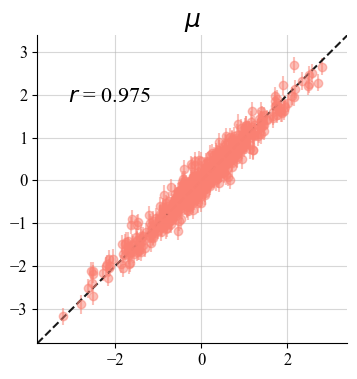

In [81]:
test_sims = trainer.configurator(model(500))
post_samples = amortizer_df1_001.sample(test_sims, n_samples=150)
plt.rcParams['font.family'] = 'Times New Roman'

try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='salmon',add_r2=False)
    plt.show()
    
except Exception as e:
    # Suppress the error and continue execution
    pass

plt.savefig(root_dir /"plots/parameter_recovery_normal_pi001.pdf", format="pdf", bbox_inches="tight")

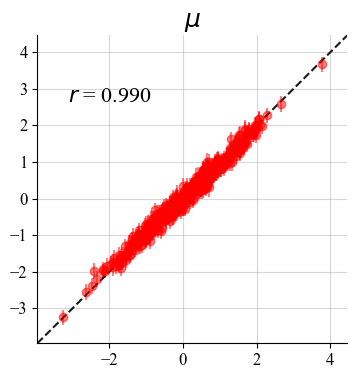

In [13]:
test_sims = trainer.configurator(model(500))
post_samples = amortizer_df1_005.sample(test_sims, n_samples=150)
plt.rcParams['font.family'] = 'Times New Roman'

try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='red',add_r2=False)
    plt.show()
    
except Exception as e:
    # Suppress the error and continue execution
    pass

plt.savefig(root_dir /"plots/parameter_recovery_normal_pi005.pdf", format="pdf", bbox_inches="tight")

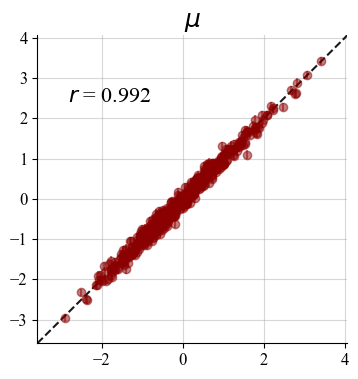

In [16]:
test_sims = trainer.configurator(model(500))
post_samples = amortizer_df1.sample(test_sims, n_samples=150)
plt.rcParams['font.family'] = 'Times New Roman'

try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='darkred',add_r2=False)
    plt.show()
    
except Exception as e:
    # Suppress the error and continue execution
    pass

plt.savefig(root_dir /"plots/parameter_recovery_normal_pi010.pdf", format="pdf", bbox_inches="tight")

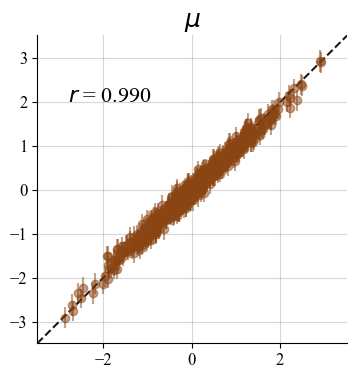

In [17]:
test_sims = trainer.configurator(model(500))
post_samples = amortizer_df1_020.sample(test_sims, n_samples=150)
plt.rcParams['font.family'] = 'Times New Roman'

try:
    f = bf.diagnostics.plot_recovery(post_samples, test_sims["parameters"],param_names=prior.param_names,point_agg=np.mean, uncertainty_agg=np.std,color='saddlebrown',add_r2=False)
    plt.show()
    
except Exception as e:
    # Suppress the error and continue execution
    pass

plt.savefig(root_dir /"plots/parameter_recovery_normal_pi020.pdf", format="pdf", bbox_inches="tight")